# A.0 Data loading & Cleaning

TAREA 2 - ALLENDE - CASTILLO


In [1]:
#Primero cargamos la librerías
import pandas as pd
import matplotlib.pyplot as plt
import re
import numpy as np
import matplotlib.ticker as mticker
import warnings
import os
from IPython.display import display
warnings.filterwarnings('ignore')

plt.rcParams.update({
    'figure.dpi': 120,
    'axes.titlesize': 12,
    'axes.labelsize': 10,
    'xtick.labelsize': 9,
    'ytick.labelsize': 9,
    'axes.spines.top': False,
    'axes.spines.right': False
})

print("Librerías cargadas correctamente.")


Librerías cargadas correctamente.


In [2]:
#A.0.1 Load the ENO Dataset
# Luego se cargan las bases de datos de ENO
eno_cols = [
    "ENO", "anho_notificacion", "region", "codigo_comuna_residencia",
    "nacionalidad", "sexo", "grupo_edad", "nombre_instruccion",
    "cie_10_diagnostico", "diagnostico", "pais_contagio"
]

eno = pd.read_csv(
    "20241218_base_eno_final.csv",
    sep=";",
    encoding="utf-8-sig",
    usecols=eno_cols
)

print("eno.shape:", eno.shape)
print("\neno.info():")
eno.info()

eno.shape: (333300, 11)

eno.info():
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 333300 entries, 0 to 333299
Data columns (total 11 columns):
 #   Column                    Non-Null Count   Dtype 
---  ------                    --------------   ----- 
 0   region                    333300 non-null  object
 1   nacionalidad              333300 non-null  object
 2   cie_10_diagnostico        333300 non-null  object
 3   diagnostico               333300 non-null  object
 4   anho_notificacion         333300 non-null  int64 
 5   ENO                       333300 non-null  object
 6   nombre_instruccion        333300 non-null  object
 7   pais_contagio             333300 non-null  object
 8   sexo                      333300 non-null  object
 9   grupo_edad                333300 non-null  object
 10  codigo_comuna_residencia  333300 non-null  object
dtypes: int64(1), object(10)
memory usage: 28.0+ MB


In [3]:
#A.0.2 Filter the comunas 
#Defino las comunas que me asignaron para el análisis. En este caso, Ñuñoa, San Joaquín y San José de Maipo.
MY_COMUNAS = [13120, 13129, 13203]  # Ñuñoa, San Joaquín, San José de Maipo

# Asegurarse que es un string
eno["codigo_comuna_residencia"] = eno["codigo_comuna_residencia"].astype(str)

# Filtrar las comunas asignadas y contar las filas
my_comunas_str = [str(c) for c in MY_COMUNAS]
eno_com = eno[eno["codigo_comuna_residencia"].isin(my_comunas_str)].copy()

print(f"Rows in my comunas: {len(eno_com):,}")

# Contar filas con código de comuna de residencia anonimizado
anon_count = (eno["codigo_comuna_residencia"] == "*****").sum()
anon_pct = 100 * anon_count / len(eno)

print(f'Anonymized rows in full ENO dataset: {anon_count:,}')
print(f"Share anonymized: {anon_pct:.2f}%")

Rows in my comunas: 2,594
Anonymized rows in full ENO dataset: 148,217
Share anonymized: 44.47%


De los 333.300 registros de la base ENO, 148.217 se encuentran anonimizados. Esto implica una limitación importante para el análisis, ya que una proporción considerable de los datos no puede asignarse a una comuna específica. En consecuencia, los resultados obtenidos probablemente no reflejan completamente la realidad y pueden subestimar la verdadera magnitud del fenómeno analizado.

In [4]:
# A.0.3 Clean the nationality variable
# 1. Distribución completa
nac_table = (
    eno_com["nacionalidad"]
    .value_counts(dropna=False)
    .rename_axis("nacionalidad")
    .reset_index(name="frecuencia")
)

nac_table["porcentaje"] = (nac_table["frecuencia"] / len(eno_com) * 100).round(2)

print("Distribución de nacionalidad en la muestra filtrada:")
print(nac_table)

# 2. Excluir 'Desconocido' para análisis específicos
drop_desconocido = (eno_com["nacionalidad"] == "Desconocido").sum()
eno_com_nac = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()

print(f"\nFilas eliminadas por nacionalidad = 'Desconocido': {drop_desconocido:,}")
print(f"Filas restantes para análisis por nacionalidad: {len(eno_com_nac):,}")

Distribución de nacionalidad en la muestra filtrada:
  nacionalidad  frecuencia  porcentaje
0        Chile        1253       48.30
1  Desconocido         914       35.24
2   Extranjero         427       16.46

Filas eliminadas por nacionalidad = 'Desconocido': 914
Filas restantes para análisis por nacionalidad: 1,680


In [5]:
#A.0.4 Report the time span
rango_min = eno_com["anho_notificacion"].min()
rango_max = eno_com["anho_notificacion"].max()

print(f"El rango de años en la base filtrada va desde {rango_min} hasta {rango_max}.")

notificaciones_anuales = (
    eno_com.groupby("anho_notificacion")
    .size()
    .reset_index(name="n_notificaciones")
    .sort_values("anho_notificacion")
)

notificaciones_anuales

El rango de años en la base filtrada va desde 2007 hasta 2024.


,anho_notificacion,n_notificaciones
0,2007,101
1,2008,81
2,2009,63
3,2010,78
4,2011,151
5,2012,108
6,2013,93
7,2014,88
8,2015,109
9,2016,95


# A.1 Notification Trends Over Time 

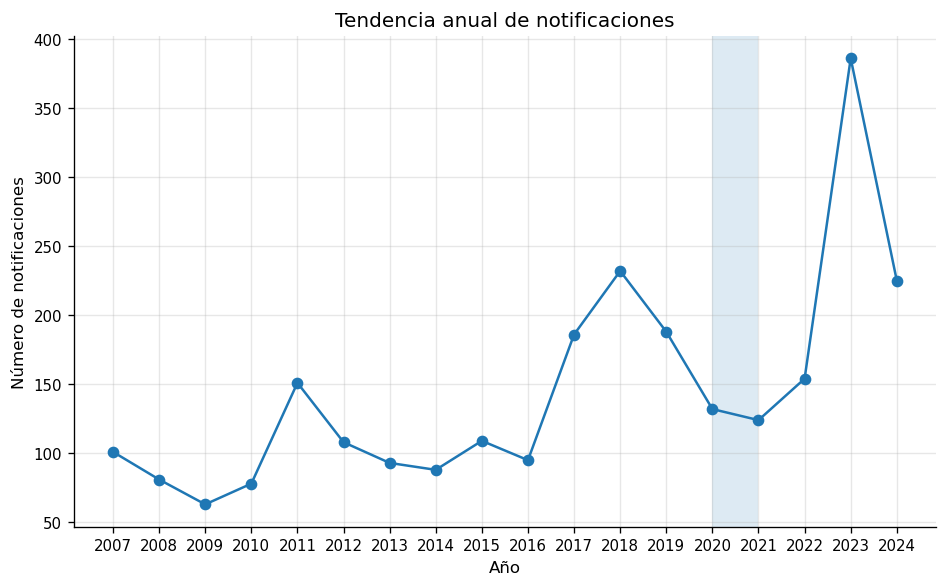

In [6]:
#A.1.1 Overall trend

notif_year = (
    eno_com.groupby("anho_notificacion")
    .size()
    .reset_index(name="n_notificaciones")
    .sort_values("anho_notificacion")
)

plt.figure(figsize=(8, 5))
plt.plot(
    notif_year["anho_notificacion"],
    notif_year["n_notificaciones"],
    marker="o"
)

# Aca dejamos sombreado el período COVID aproximado
plt.axvspan(2020, 2021, alpha=0.15)

plt.title("Tendencia anual de notificaciones")
plt.xlabel("Año")
plt.ylabel("Número de notificaciones")
plt.xticks(notif_year["anho_notificacion"])
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Filas excluidas por nacionalidad = 'Desconocido': 914
Filas restantes para análisis por nacionalidad: 1,680

Tabla de notificaciones por año y nacionalidad:
nacionalidad       Chile  Extranjero
anho_notificacion                   
2007                36.0         4.0
2008                25.0         1.0
2009                27.0         0.0
2010                33.0         0.0
2011                65.0         4.0
2012                 3.0         1.0
2013                 5.0         3.0
2014                 7.0         4.0
2015                57.0         6.0
2016                48.0         7.0
2017                54.0        28.0
2018                45.0        35.0
2019               135.0        44.0
2020                92.0        36.0
2021                90.0        28.0
2022               103.0        43.0
2023               265.0       121.0
2024               163.0        62.0


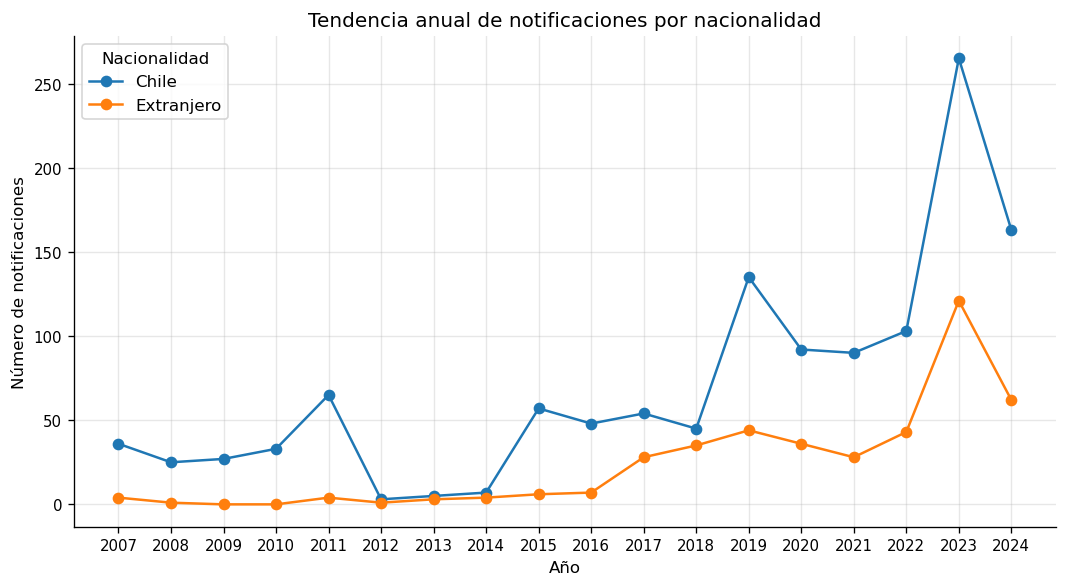

In [7]:
#A.1.2 Trend by nationality
# Excluir nacionalidad desconocida, pero reportarlo
drop_desconocido = (eno_com["nacionalidad"] == "Desconocido").sum()
eno_com_nac = eno_com[eno_com["nacionalidad"] != "Desconocido"].copy()

print(f"Filas excluidas por nacionalidad = 'Desconocido': {drop_desconocido:,}")
print(f"Filas restantes para análisis por nacionalidad: {len(eno_com_nac):,}")

# Mantener solo Chile y Extranjero
eno_com_nac = eno_com_nac[eno_com_nac["nacionalidad"].isin(["Chile", "Extranjero"])].copy()

# Conteo por año y nacionalidad
trend_nac = (
    eno_com_nac
    .groupby(["anho_notificacion", "nacionalidad"])
    .size()
    .reset_index(name="n_notificaciones")
)

# Pasar a formato ancho para graficar
trend_nac_wide = (
    trend_nac
    .pivot(index="anho_notificacion", columns="nacionalidad", values="n_notificaciones")
    .fillna(0)
    .sort_index()
)

print("\nTabla de notificaciones por año y nacionalidad:")
print(trend_nac_wide)

# Gráfico de líneas
plt.figure(figsize=(9, 5))

for col in trend_nac_wide.columns:
    plt.plot(
        trend_nac_wide.index,
        trend_nac_wide[col],
        marker="o",
        label=col
    )

plt.title("Tendencia anual de notificaciones por nacionalidad")
plt.xlabel("Año")
plt.ylabel("Número de notificaciones")
plt.xticks(trend_nac_wide.index)
plt.legend(title="Nacionalidad")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

Hasta el 2014 no habian casi notificaciones de extranjeros, de ahi hubo una tendencia al alza hasta el 2019, de ahi en adelante las notificaciones extranjeras han seguido la tendencia de las notificaciones chilenas pero en menor proporción.

# A.2 Disease Profile

Top 10 enfermedades notificadas (ENO):
ENO
Fiebre Tifoidea y Paratifoidea      29
Hidatidosis (Equinococosis)         30
Hepatitis C                         34
Enfermedad meningocócica            37
Infección gonocócica                62
Chagas                             106
Sifilis                            247
Coqueluche                         334
Parotiditis                        549
VIH                               1031
Name: count, dtype: int64


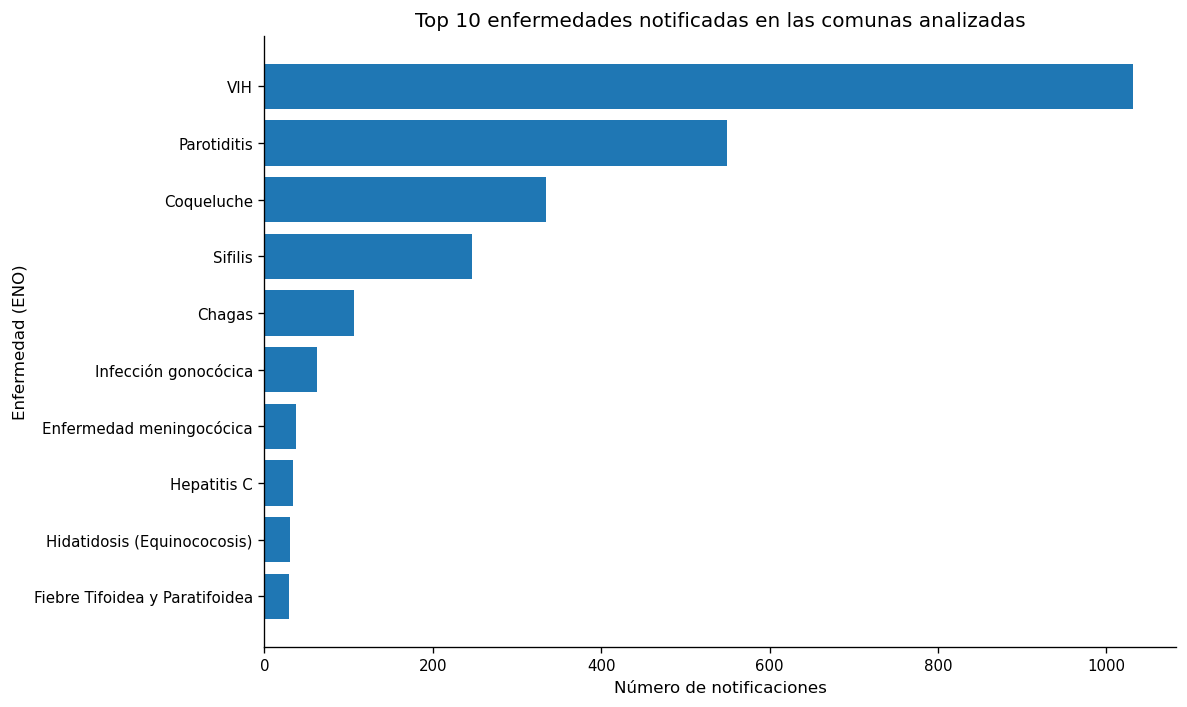

In [8]:
#A.2.1 Top diseases overall
# Top 10 enfermedades notificadas según la columna ENO
top10_eno = (
    eno_com["ENO"]
    .value_counts()
    .head(10)
    .sort_values(ascending=True)   # para que el gráfico horizontal quede ordenado
)

print("Top 10 enfermedades notificadas (ENO):")
print(top10_eno)

# Gráfico de barras horizontales
plt.figure(figsize=(10, 6))
plt.barh(top10_eno.index, top10_eno.values)

plt.title("Top 10 enfermedades notificadas en las comunas analizadas")
plt.xlabel("Número de notificaciones")
plt.ylabel("Enfermedad (ENO)")
plt.tight_layout()
plt.show()

In [9]:
# 1) Reportar cuántas filas se excluyen por nacionalidad desconocida
drop_desconocido = (eno_com["nacionalidad"] == "Desconocido").sum()
print(f"Filas excluidas por nacionalidad = 'Desconocido': {drop_desconocido:,}")

# 2) Top 5 enfermedades overall (según ENO)
top5_diseases = eno_com["ENO"].value_counts().head(5).index.tolist()
print("\nTop 5 enfermedades:")
print(top5_diseases)

# 3) Filtrar a top 5 + excluir nacionalidad desconocida
eno_top5_nac = eno_com[
    eno_com["ENO"].isin(top5_diseases) &
    (eno_com["nacionalidad"] != "Desconocido")
].copy()

# 4) Conteos por enfermedad y nacionalidad
top5_nac_counts = (
    eno_top5_nac
    .groupby(["ENO", "nacionalidad"])
    .size()
    .reset_index(name="n_notificaciones")
)

print("\nConteos por enfermedad y nacionalidad:")
print(top5_nac_counts)

# 5) Pasar a formato ancho
top5_nac_wide = (
    top5_nac_counts
    .pivot(index="ENO", columns="nacionalidad", values="n_notificaciones")
    .fillna(0)
)

# Asegurar que existan ambas columnas
for col in ["Chile", "Extranjero"]:
    if col not in top5_nac_wide.columns:
        top5_nac_wide[col] = 0

top5_nac_wide = top5_nac_wide[["Chile", "Extranjero"]]

# 6) Calcular shares dentro de cada enfermedad
top5_nac_share = top5_nac_wide.div(top5_nac_wide.sum(axis=1), axis=0) * 100

# Ordenar por share de extranjeros para visualizar mejor
top5_nac_share = top5_nac_share.sort_values("Extranjero", ascending=True)

print("\nPorcentaje por enfermedad:")
print(top5_nac_share.round(2))

Filas excluidas por nacionalidad = 'Desconocido': 914

Top 5 enfermedades:
['VIH', 'Parotiditis', 'Coqueluche', 'Sifilis', 'Chagas']

Conteos por enfermedad y nacionalidad:
           ENO nacionalidad  n_notificaciones
0       Chagas        Chile                96
1       Chagas   Extranjero                 9
2   Coqueluche        Chile                22
3   Coqueluche   Extranjero                 6
4  Parotiditis        Chile               164
5  Parotiditis   Extranjero                13
6      Sifilis        Chile               166
7      Sifilis   Extranjero                81
8          VIH        Chile               602
9          VIH   Extranjero               276

Porcentaje por enfermedad:
nacionalidad  Chile  Extranjero
ENO                            
Parotiditis   92.66        7.34
Chagas        91.43        8.57
Coqueluche    78.57       21.43
VIH           68.56       31.44
Sifilis       67.21       32.79


In [10]:
#Para entender mejor estos resultados, se ha ido mas al detalle para comparar con el porcentaje de extranjeros
#en estas comunas, siendo:  San José de Maipo = 4.76%; San Joaquín = 14.82%; Ñuñoa = 14.05%
# Mapear códigos a nombres de comuna
comuna_map = {
    "13120": "Ñuñoa",
    "13129": "San Joaquín",
    "13203": "San José de Maipo"
}

eno_com["comuna"] = eno_com["codigo_comuna_residencia"].astype(str).map(comuna_map)

#Total de notificaciones por comuna y enfermedad (incluye todas las nacionalidades)
totales = (
    eno_com
    .groupby(["comuna", "ENO"])
    .size()
    .reset_index(name="n_notificaciones_totales")
)

#Contar cuántos "Desconocido" hay por comuna y enfermedad
desconocidos = (
    eno_com[eno_com["nacionalidad"] == "Desconocido"]
    .groupby(["comuna", "ENO"])
    .size()
    .reset_index(name="n_desconocido")
)

#Base solo con nacionalidad conocida para calcular porcentaje de extranjeros
eno_known = eno_com[eno_com["nacionalidad"].isin(["Chile", "Extranjero"])].copy()

n_drop = (eno_com["nacionalidad"] == "Desconocido").sum()
print(f"Filas excluidas para calcular porcentaje de extranjeros: {n_drop:,}")

#Calcular porcentaje de extranjeros por comuna y enfermedad
nac_stats = (
    eno_known
    .groupby(["comuna", "ENO", "nacionalidad"])
    .size()
    .reset_index(name="n")
)

nac_wide = (
    nac_stats
    .pivot(index=["comuna", "ENO"], columns="nacionalidad", values="n")
    .fillna(0)
    .reset_index()
)

# Asegurar columnas
for col in ["Chile", "Extranjero"]:
    if col not in nac_wide.columns:
        nac_wide[col] = 0

nac_wide["pct_extranjeros"] = (
    nac_wide["Extranjero"] / (nac_wide["Chile"] + nac_wide["Extranjero"]) * 100
).round(2)

pct_table = nac_wide[["comuna", "ENO", "pct_extranjeros"]]

#Unir tablas
tabla_final = (
    totales
    .merge(pct_table, on=["comuna", "ENO"], how="left")
    .merge(desconocidos, on=["comuna", "ENO"], how="left")
)

tabla_final["n_desconocido"] = tabla_final["n_desconocido"].fillna(0).astype(int)

# 6) Ordenar por comuna y número total de notificaciones, y quedarse con top 5 por comuna
tabla_final = (
    tabla_final
    .sort_values(["comuna", "n_notificaciones_totales"], ascending=[True, False])
    .groupby("comuna")
    .head(5)
    .reset_index(drop=True)
)

#Renombrar columnas para que quede más limpio
tabla_final = tabla_final.rename(columns={
    "ENO": "enfermedad"
})

# Mostrar solo las columnas solicitadas
resultado = tabla_final[[
    "comuna",
    "enfermedad",
    "pct_extranjeros",
    "n_notificaciones_totales"
]]

print(resultado)

Filas excluidas para calcular porcentaje de extranjeros: 914
               comuna   enfermedad  pct_extranjeros  n_notificaciones_totales
0         San Joaquín          VIH            38.10                       339
1         San Joaquín  Parotiditis            11.76                       140
2         San Joaquín   Coqueluche            14.29                        83
3         San Joaquín      Sifilis            30.49                        82
4         San Joaquín       Chagas            13.33                        31
5   San José de Maipo          VIH            22.22                        41
6   San José de Maipo  Parotiditis             0.00                        18
7   San José de Maipo   Coqueluche             0.00                        12
8   San José de Maipo       Chagas             0.00                        10
9   San José de Maipo      Sifilis            50.00                         4
10              Ñuñoa          VIH            28.47                       651
11 

Al comparar la proporción de notificaciones de personas extranjeras con su peso dentro de la población comunal, se observa que en varias enfermedades su participación es mayor a la esperada según su tamaño poblacional. Dentro de los datos destaco que de las notificaciones de VIH en extranjeros de San Joaquin bordan el 40%, que en San José de Maipo hay pocas notificaciones, siendo que si sumo las 5 enfermedades mas notificadas de esta comuna no alcanzan las 100 notificaciones y que los extranjeron tienden a tener menos Parotiditis.

Enfermedad más frecuente: VIH
Total de notificaciones: 1,031
Filas excluidas por nacionalidad = 'Desconocido': 153

Conteos por grupo etario y nacionalidad:
nacionalidad  Chile  Extranjero
grupo_edad                     
00-04           2.0         0.0
15-19          20.0         3.0
20-24          75.0        24.0
25-29         131.0        63.0
30-34         118.0        90.0
35-39          75.0        43.0
40-44          64.0        28.0
45-49          48.0        16.0
50-54          28.0         6.0
55-59          22.0         1.0
60-64           9.0         0.0
65-69           3.0         1.0
70-74           5.0         0.0
75-79           1.0         0.0
***             1.0         1.0

Porcentajes por grupo etario dentro de cada nacionalidad:
nacionalidad  Chile  Extranjero
grupo_edad                     
00-04          0.33        0.00
15-19          3.32        1.09
20-24         12.46        8.70
25-29         21.76       22.83
30-34         19.60       32.61
35-39         12

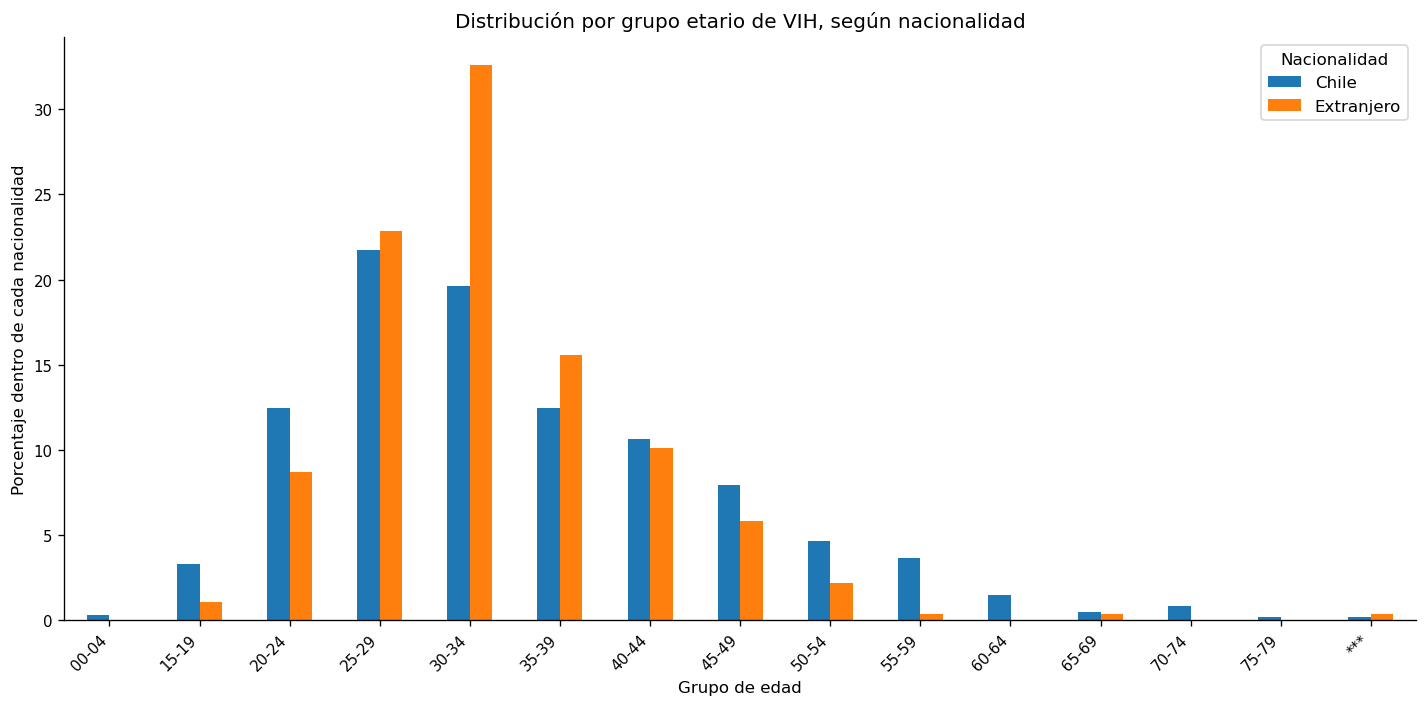

In [11]:

# Identificar la enfermedad más frecuente en tus comunas
top_disease = eno_com["ENO"].value_counts().idxmax()
top_disease_n = eno_com["ENO"].value_counts().max()

print(f"Enfermedad más frecuente: {top_disease}")
print(f"Total de notificaciones: {top_disease_n:,}")

# Filtrar a esa enfermedad
eno_top = eno_com[eno_com["ENO"] == top_disease].copy()

#Reportar y excluir nacionalidad desconocida
drop_desconocido = (eno_top["nacionalidad"] == "Desconocido").sum()
print(f"Filas excluidas por nacionalidad = 'Desconocido': {drop_desconocido:,}")

eno_top = eno_top[eno_top["nacionalidad"].isin(["Chile", "Extranjero"])].copy()

#Ordenar grupos de edad de forma razonable
def age_sort_key(x):
    if pd.isna(x):
        return 9999
    s = str(x).strip().lower()
    if "menor" in s:
        return -1
    nums = re.findall(r"\d+", s)
    return int(nums[0]) if nums else 9999

age_order = sorted(eno_top["grupo_edad"].dropna().unique(), key=age_sort_key)

#Tabla de conteos por grupo etario y nacionalidad
age_nat_counts = (
    eno_top
    .groupby(["grupo_edad", "nacionalidad"])
    .size()
    .reset_index(name="n_notificaciones")
)

age_nat_wide = (
    age_nat_counts
    .pivot(index="grupo_edad", columns="nacionalidad", values="n_notificaciones")
    .fillna(0)
)

for col in ["Chile", "Extranjero"]:
    if col not in age_nat_wide.columns:
        age_nat_wide[col] = 0

age_nat_wide = age_nat_wide[["Chile", "Extranjero"]].reindex(age_order).fillna(0)

print("\nConteos por grupo etario y nacionalidad:")
print(age_nat_wide)

#Convertir a porcentajes dentro de cada nacionalidad
age_nat_pct = (age_nat_wide.div(age_nat_wide.sum(axis=0), axis=1) * 100).round(2)

print("\nPorcentajes por grupo etario dentro de cada nacionalidad:")
print(age_nat_pct)

#Gráfico
ax = age_nat_pct.plot(kind="bar", figsize=(12, 6))

plt.title(f"Distribución por grupo etario de {top_disease}, según nacionalidad")
plt.xlabel("Grupo de edad")
plt.ylabel("Porcentaje dentro de cada nacionalidad")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Nacionalidad")
plt.tight_layout()
plt.show()

Se puede ver una diferencia entre el extranjero y el chileno, siendo que en el primer grupo nombrado tienen mas notificaciones de VIH con una edad de 30-34, en cambio los chilenos poseen este auge de aviso de enfermedad a los 25-29

 # A.3 Spatial View 

In [12]:
#Con los valoras de las comunas mapeados
eno_com["comuna"] = eno_com["codigo_comuna_residencia"].astype(str).map(comuna_map)

# Total de notificaciones por comuna
notif_comuna = (
    eno_com
    .groupby("comuna")
    .size()
    .reset_index(name="n_notificaciones")
    .sort_values("n_notificaciones", ascending=False)
)

print(notif_comuna)

              comuna  n_notificaciones
2              Ñuñoa              1735
0        San Joaquín               767
1  San José de Maipo                92


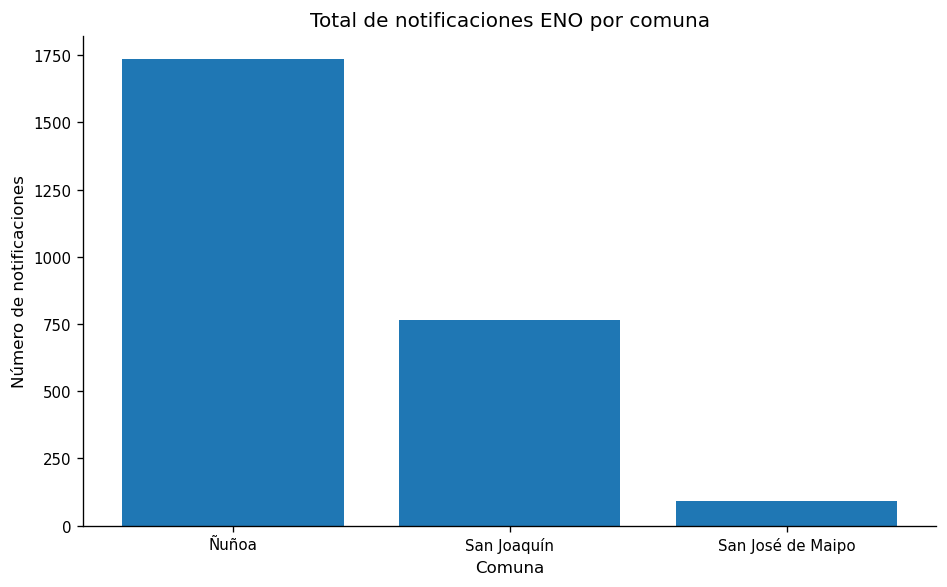

In [13]:
plt.figure(figsize=(8, 5))
plt.bar(notif_comuna["comuna"], notif_comuna["n_notificaciones"])

plt.title("Total de notificaciones ENO por comuna")
plt.xlabel("Comuna")
plt.ylabel("Número de notificaciones")
plt.tight_layout()
plt.show()

In [ ]:
# Población real de tu tabla resumen de Tarea 1
poblacion_comuna = {
    "Ñuñoa": 239323,
    "San Joaquín": 95039,
    "San José de Maipo": 17303
}

notif_comuna["poblacion"] = notif_comuna["comuna"].map(poblacion_comuna)

notif_comuna["tasa_por_10000"] = (
    notif_comuna["n_notificaciones"] / notif_comuna["poblacion"] * 10000
).round(2)

print(notif_comuna)

              comuna  n_notificaciones  poblacion  tasa_por_10000
2              Ñuñoa              1735     239323           72.50
0        San Joaquín               767      95039           80.70
1  San José de Maipo                92      17303           53.17


# A.4 Comuna-Level ENO Summary Table

In [17]:

# =========================================================
# 1. Base de comunas construida manualmente
# =========================================================
base_comunas = pd.DataFrame({
    "codigo_comuna": [13120, 13129, 13203],   
    "nombre_comuna": ["Ñuñoa", "San Joaquín", "San José de Maipo"],
    "pop_total": [239323, 95039, 17303]
})

# Asegurar tipo numérico
base_comunas["codigo_comuna"] = pd.to_numeric(
    base_comunas["codigo_comuna"], errors="coerce"
).astype("Int64")

# =========================================================
# 2. Preparar ENO
# =========================================================
eno_com = eno_com.copy()

eno_com["codigo_comuna_residencia"] = pd.to_numeric(
    eno_com["codigo_comuna_residencia"], errors="coerce"
).astype("Int64")

# Detectar columna de enfermedad/evento
disease_candidates = [
    "enfermedad",
    "nombre_enfermedad",
    "evento",
    "nombre_evento",
    "glosa_evento",
    "diagnostico"
]

disease_col = next((c for c in disease_candidates if c in eno_com.columns), None)

if disease_col is None:
    raise ValueError(
        "No encontré la columna de enfermedad/evento en eno_com. "
        "Debes ponerla manualmente, por ejemplo: disease_col = 'evento'"
    )

# =========================================================
# 3. Estandarizar nacionalidad
# =========================================================
eno_com["nacionalidad_std"] = (
    eno_com["nacionalidad"]
    .fillna("Desconocido")
    .astype(str)
    .str.strip()
)

eno_com["nacionalidad_std"] = eno_com["nacionalidad_std"].replace({
    "Chilena": "Chile",
    "chilena": "Chile",
    "Chile": "Chile",
    "Extranjera": "Extranjero",
    "extranjera": "Extranjero",
    "Extranjero": "Extranjero",
    "No informa": "Desconocido",
    "No informado": "Desconocido",
    "": "Desconocido"
})

eno_com.loc[
    ~eno_com["nacionalidad_std"].isin(["Chile", "Extranjero", "Desconocido"]),
    "nacionalidad_std"
] = "Desconocido"

# =========================================================
# 4. Funciones auxiliares
# =========================================================
def top3_diseases(series):
    s = series.dropna().astype(str).str.strip()
    s = s[s != ""]
    return ", ".join(s.value_counts().head(3).index.tolist())

def build_eno_summary(df):
    return pd.Series({
        "eno_total": len(df),
        "eno_chilean": (df["nacionalidad_std"] == "Chile").sum(),
        "eno_foreign": (df["nacionalidad_std"] == "Extranjero").sum(),
        "eno_desconocido": (df["nacionalidad_std"] == "Desconocido").sum(),
        "eno_top3_diseases": top3_diseases(df[disease_col])
    })

# =========================================================
# 5. Resumen ENO por comuna
# =========================================================
eno_summary_raw = (
    eno_com.groupby("codigo_comuna_residencia")
    .apply(build_eno_summary)
    .reset_index()
    .rename(columns={"codigo_comuna_residencia": "codigo_comuna"})
)

# Unir con base manual
eno_summary = base_comunas.merge(
    eno_summary_raw,
    on="codigo_comuna",
    how="left"
)

# Completar comunas sin casos
count_cols = ["eno_total", "eno_chilean", "eno_foreign", "eno_desconocido"]
eno_summary[count_cols] = eno_summary[count_cols].fillna(0).astype(int)
eno_summary["eno_top3_diseases"] = eno_summary["eno_top3_diseases"].fillna("")

# Tasa por 10.000 habitantes
eno_summary["eno_rate_per_10k"] = np.where(
    eno_summary["pop_total"] > 0,
    (eno_summary["eno_total"] / eno_summary["pop_total"]) * 10000,
    np.nan
).round(2)

# Orden final de columnas
eno_summary = eno_summary[
    [
        "codigo_comuna",
        "nombre_comuna",
        "eno_total",
        "eno_chilean",
        "eno_foreign",
        "eno_desconocido",
        "eno_top3_diseases",
        "eno_rate_per_10k"
    ]
].sort_values(["eno_total", "codigo_comuna"], ascending=[False, True]).reset_index(drop=True)

# =========================================================
# 6. Mostrar y guardar
# =========================================================
os.makedirs("output", exist_ok=True)
eno_summary.to_csv("output/tarea2_eno_summary.csv", index=False, encoding="utf-8-sig")

display(eno_summary)

,codigo_comuna,nombre_comuna,eno_total,eno_chilean,eno_foreign,eno_desconocido,eno_top3_diseases,eno_rate_per_10k
0,13120,Ñuñoa,1735,830,255,650,"no aplica, PAROTIDITIS, SIN COMPLICACIONES, TO...",72.50
1,13129,San Joaquín,767,372,161,234,"no aplica, PAROTIDITIS, SIN COMPLICACIONES, TO...",80.70
2,13203,San José de Maipo,92,51,11,30,"no aplica, PAROTIDITIS, SIN COMPLICACIONES, TO...",53.17


# Tarea 2 — Parte B: Análisis de Egresos Hospitalarios GRD
**Comunas asignadas:** Ñuñoa, San Joaquín, San José de Maipo  
**Años analizados:** 2022, 2023, 2024  

---
## B.0 Carga y preparación de datos

Se cargan las tres bases GRD (2022-2024). Los archivos 2022 y 2023 están en codificación UTF-16 LE (con BOM), mientras que el archivo 2024 usa Latin-1. Todos usan `|` como separador. Solo se cargan las columnas relevantes para el análisis para reducir el uso de memoria.

In [ ]:
# Columnas a leer en los tres archivos (mismas en los tres años)
COLS = [
    'COD_HOSPITAL', 'SEXO', 'FECHA_NACIMIENTO', 'PROVINCIA', 'COMUNA',
    'NACIONALIDAD', 'PREVISION', 'TIPO_PROCEDENCIA', 'TIPO_INGRESO',
    'TIPO_ACTIVIDAD', 'FECHA_INGRESO', 'FECHAALTA', 'TIPOALTA',
    'DIAGNOSTICO1', 'IR_29301_COD_GRD', 'IR_29301_PESO',
    'IR_29301_SEVERIDAD', 'IR_29301_MORTALIDAD'
]

def cargar_grd(ruta, codificacion, anio):
    """Carga un archivo GRD, normaliza texto y agrega columna de año."""
    df = pd.read_csv(
        ruta, sep='|', encoding=codificacion,
        usecols=COLS, low_memory=False, dtype=str
    )
    df['AÑO'] = anio
    for col in df.select_dtypes('object').columns:
        df[col] = df[col].str.strip()
    return df

print("Cargando GRD 2022 (UTF-16)...")
grd22 = cargar_grd('GRD_PUBLICO_EXTERNO_2022.txt', 'utf-16', 2022)
print(f"  → {len(grd22):,} registros")

print("Cargando GRD 2023 (UTF-16)...")
grd23 = cargar_grd('GRD_PUBLICO_2023.txt', 'utf-16', 2023)
print(f"  → {len(grd23):,} registros")

print("Cargando GRD 2024 (Latin-1)...")
grd24 = cargar_grd('GRD_PUBLICO_2024.txt', 'latin-1', 2024)
print(f"  → {len(grd24):,} registros")

grd = pd.concat([grd22, grd23, grd24], ignore_index=True)
print(f"\nTotal registros nacionales (2022-2024): {len(grd):,}")

Cargando GRD 2022 (UTF-16)...
  → 932,840 registros
Cargando GRD 2023 (UTF-16)...
  → 1,039,587 registros
Cargando GRD 2024 (Latin-1)...
  → 1,085,813 registros

Total registros nacionales (2022-2024): 3,058,240


---
## B.1 Filtrado de comunas asignadas y cálculo de días de hospitalización

Se filtra la base a las tres comunas asignadas: **Ñuñoa**, **San Joaquín** y **San José de Maipo**. Luego se calculan los días de hospitalización como la diferencia entre `FECHAALTA` y `FECHA_INGRESO`. Se eliminan los registros con días negativos o fechas faltantes, que corresponden a errores de registro.

In [ ]:
MY_COMUNAS = ['ÑUÑOA', 'SAN JOAQUÍN', 'SAN JOSÉ DE MAIPO']

grd_com = grd[grd['COMUNA'].isin(MY_COMUNAS)].copy()
print(f"Registros en comunas asignadas: {len(grd_com):,}")
print("\nDistribución por comuna y año:")
print(grd_com.groupby(['COMUNA', 'AÑO']).size().unstack(fill_value=0).to_string())

# Parseo de fechas (los archivos 2022/2023 usan DD-MM-YYYY; 2024 usa YYYY-MM-DD)
for col in ['FECHA_INGRESO', 'FECHAALTA', 'FECHA_NACIMIENTO']:
    grd_com[col] = pd.to_datetime(
        grd_com[col], format='mixed', dayfirst=True, errors='coerce'
    )

# Días de hospitalización
grd_com['DIAS_HOSP'] = (grd_com['FECHAALTA'] - grd_com['FECHA_INGRESO']).dt.days

n_invalidos = ((grd_com['DIAS_HOSP'] < 0) | grd_com['DIAS_HOSP'].isna()).sum()
print(f"\nRegistros con días inválidos (excluidos): {n_invalidos}")
grd_com = grd_com[grd_com['DIAS_HOSP'] >= 0].copy()
print(f"Registros válidos para análisis: {len(grd_com):,}")

Registros en comunas asignadas: 35,933

Distribución por comuna y año:
AÑO                2022  2023  2024
COMUNA                             
SAN JOAQUÍN        4493  4434  4764
SAN JOSÉ DE MAIPO   951  1032  1111
ÑUÑOA              5921  6454  6773

Registros con días inválidos (excluidos): 3592
Registros válidos para análisis: 32,341


---
## B.2 Días de hospitalización

Se analiza la distribución de días de estadía para cada comuna. Las estadísticas descriptivas incluyen media, mediana y percentiles. Se usa el percentil 99 para acotar los *outliers* extremos en la visualización (casos muy prolongados), sin eliminarlos del análisis numérico.

In [ ]:
stats = (
    grd_com.groupby('COMUNA')['DIAS_HOSP']
    .agg(
        N='count',
        Media='mean',
        Mediana='median',
        P25=lambda x: x.quantile(0.25),
        P75=lambda x: x.quantile(0.75),
        Max='max'
    )
    .round(2)
)
print("Estadísticas de días de hospitalización por comuna (2022-2024):")
display(stats)

print("\nEstadísticas por año y comuna:")
stats_anio = (
    grd_com.groupby(['COMUNA', 'AÑO'])['DIAS_HOSP']
    .agg(N='count', Media='mean', Mediana='median')
    .round(2)
    .reset_index()
)
display(stats_anio)

Estadísticas de días de hospitalización por comuna (2022-2024):


,N,Media,Mediana,P25,P75,Max
COMUNA,,,,,,
SAN JOAQUÍN,12206,23.59,3.0,1.0,18.0,628
SAN JOSÉ DE MAIPO,2844,18.85,2.0,0.0,8.0,354
ÑUÑOA,17291,20.97,2.0,0.0,12.0,600



Estadísticas por año y comuna:


,COMUNA,AÑO,N,Media,Mediana
0,SAN JOAQUÍN,2022,3770,33.25,3.5
1,SAN JOAQUÍN,2023,4434,6.22,3.0
2,SAN JOAQUÍN,2024,4002,33.75,4.0
3,SAN JOSÉ DE MAIPO,2022,838,25.52,2.0
4,SAN JOSÉ DE MAIPO,2023,1032,4.67,2.0
5,SAN JOSÉ DE MAIPO,2024,974,28.13,2.0
6,ÑUÑOA,2022,5031,30.25,3.0
7,ÑUÑOA,2023,6454,5.84,2.0
8,ÑUÑOA,2024,5806,29.74,2.0


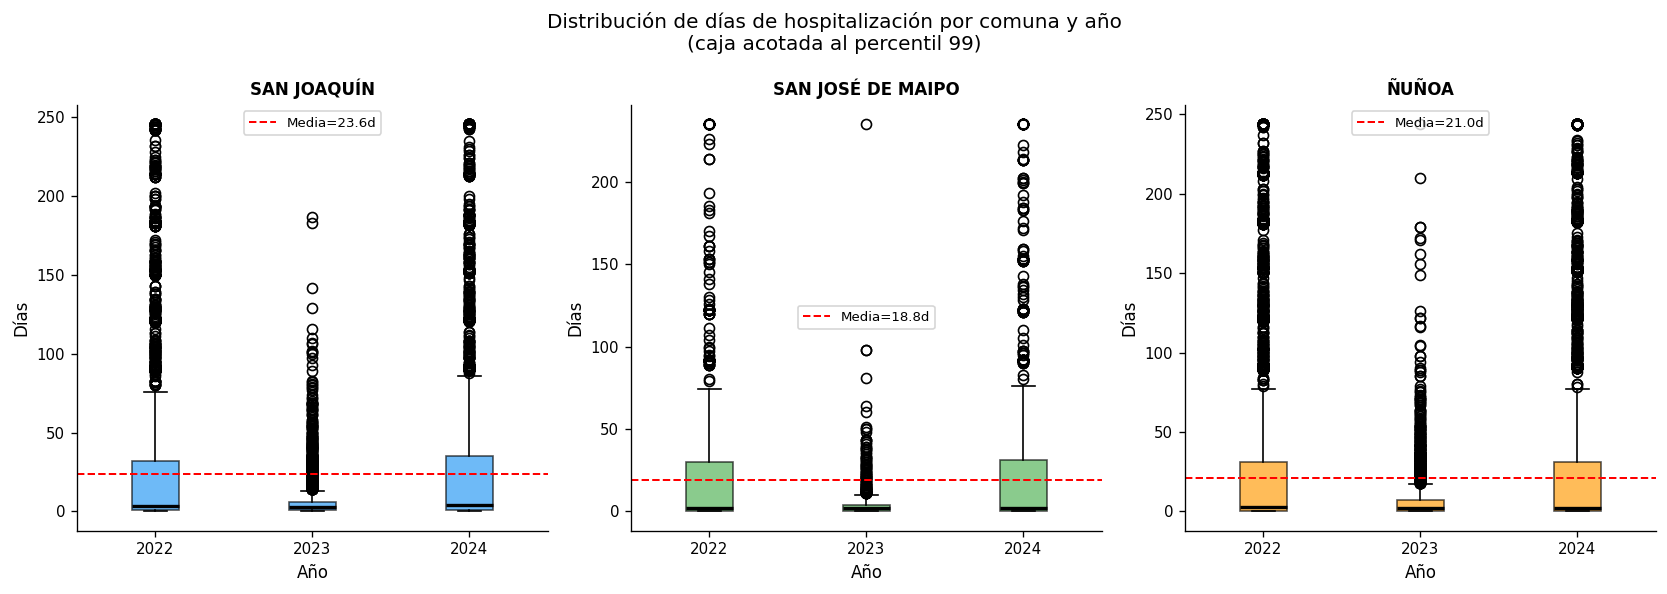

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=False)
fig.suptitle("Distribución de días de hospitalización por comuna y año\n(caja acotada al percentil 99)",
             fontsize=12)

colores = ['#2196F3', '#4CAF50', '#FF9800']

for ax, (comuna, grupo), color in zip(axes, grd_com.groupby('COMUNA'), colores):
    p99 = grupo['DIAS_HOSP'].quantile(0.99)
    años = sorted(grupo['AÑO'].unique())
    datos = [grupo[grupo['AÑO'] == a]['DIAS_HOSP'].clip(upper=p99).values for a in años]
    bp = ax.boxplot(datos, labels=[str(a) for a in años],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch in bp['boxes']:
        patch.set_facecolor(color)
        patch.set_alpha(0.65)
    media_g = grupo['DIAS_HOSP'].mean()
    ax.axhline(media_g, color='red', linestyle='--', linewidth=1.2,
               label=f'Media={media_g:.1f}d')
    ax.set_title(f"{comuna}", fontsize=10, fontweight='bold')
    ax.set_xlabel("Año")
    ax.set_ylabel("Días")
    ax.legend(fontsize=8)

plt.tight_layout()
plt.savefig('boxplot_dias_hosp.png', bbox_inches='tight', dpi=150)
plt.show()

---
## B.3 Comparación Chilenos vs Extranjeros

Se categoriza la variable `NACIONALIDAD`: los registros con valor `'CHILE'` se clasifican como **Chileno** y todos los demás como **Extranjero** (incluyendo valores desconocidos o nulos). Se compara la distribución de días de hospitalización entre ambos grupos dentro de cada comuna.

In [ ]:
print("Distribución de NACIONALIDAD (top 15 en comunas asignadas):")
print(grd_com['NACIONALIDAD'].value_counts(dropna=False).head(15).to_string())

grd_com['GRUPO_NAC'] = np.where(
    grd_com['NACIONALIDAD'].str.upper() == 'CHILE',
    'Chileno', 'Extranjero'
)

print("\nClasificación final:")
print(grd_com['GRUPO_NAC'].value_counts().to_string())
pct_ext = 100 * (grd_com['GRUPO_NAC'] == 'Extranjero').mean()
print(f"\nPorcentaje de extranjeros en las comunas asignadas: {pct_ext:.1f}%")

print("\nComparación estadísticas por comuna y grupo:")
comp = (
    grd_com.groupby(['COMUNA', 'GRUPO_NAC'])['DIAS_HOSP']
    .agg(N='count', Media='mean', Mediana='median', Std='std')
    .round(2)
    .reset_index()
)
display(comp)

Distribución de NACIONALIDAD (top 15 en comunas asignadas):
NACIONALIDAD
CHILE                                   29648
VENEZUELA (REPÚBLICA BOLIVARIANA DE)     1452
PERÚ                                      481
COLOMBIA                                  261
HAITÍ                                     109
ECUADOR                                    86
BOLIVIA (ESTADO PLURINACIONAL DE)          71
ARGENTINA                                  35
CUBA                                       28
REPÚBLICA DOMINICANA                       23
BRASIL                                     17
ITALIA                                     11
CHINA                                      11
ESPAÑA                                     10
EUROPA                                      9

Clasificación final:
GRUPO_NAC
Chileno       29648
Extranjero     2693

Porcentaje de extranjeros en las comunas asignadas: 8.3%

Comparación estadísticas por comuna y grupo:


,COMUNA,GRUPO_NAC,N,Media,Mediana,Std
0,SAN JOAQUÍN,Chileno,11098,23.48,3.0,50.68
1,SAN JOAQUÍN,Extranjero,1108,24.79,3.0,47.09
2,SAN JOSÉ DE MAIPO,Chileno,2781,18.77,2.0,44.67
3,SAN JOSÉ DE MAIPO,Extranjero,63,22.44,3.0,54.14
4,ÑUÑOA,Chileno,15769,21.22,2.0,48.74
5,ÑUÑOA,Extranjero,1522,18.40,2.0,41.42


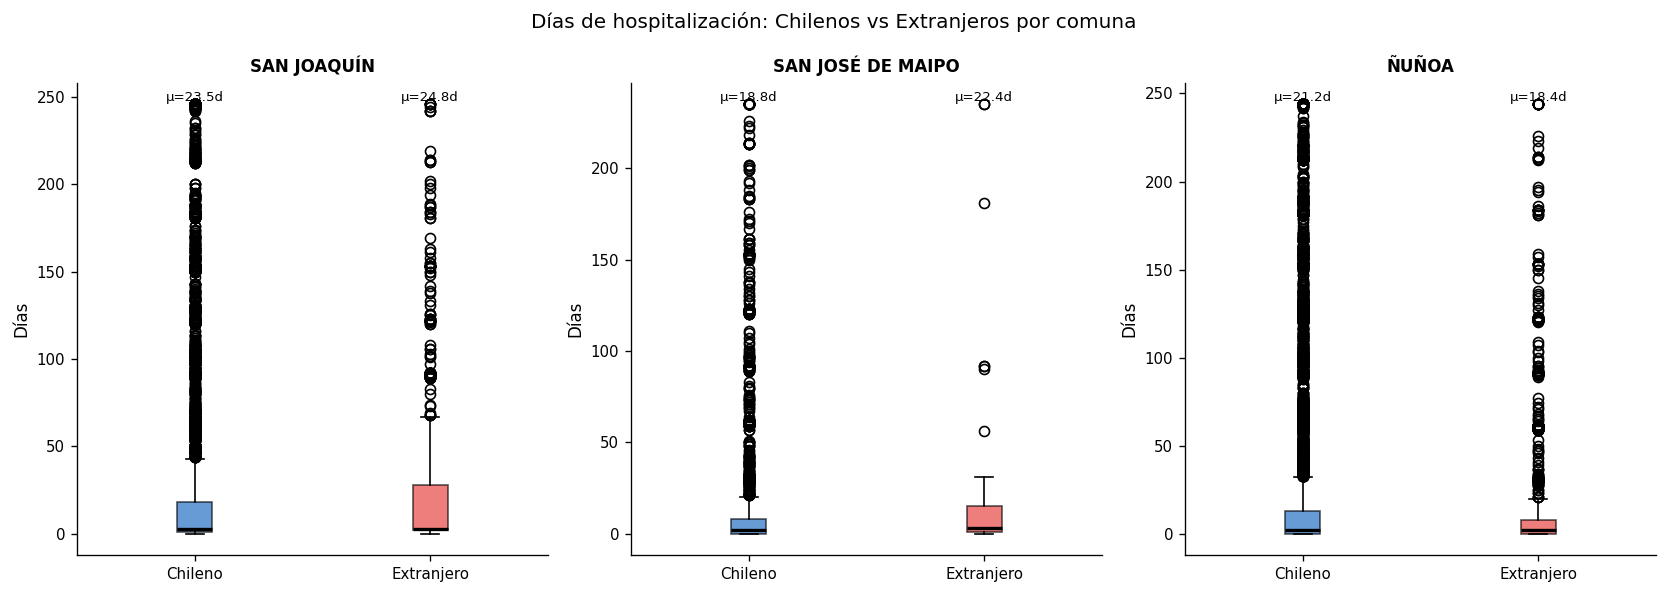

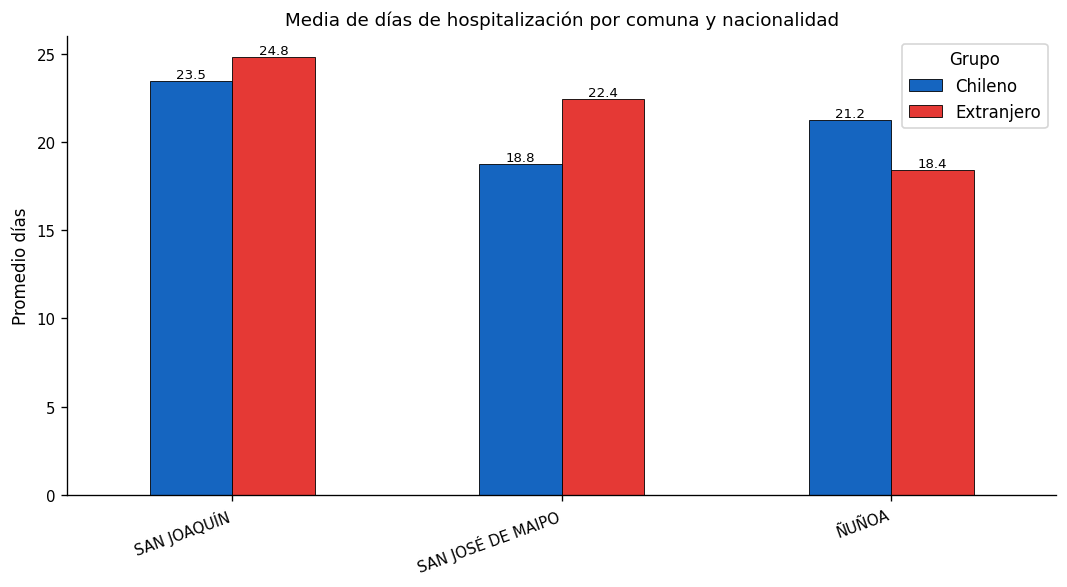

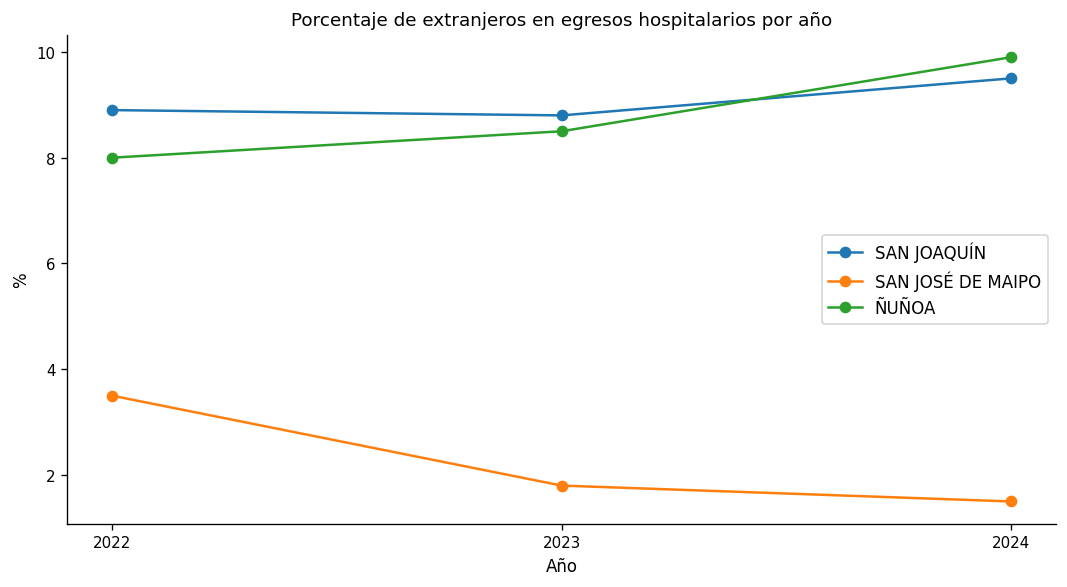

In [ ]:
COLORES_NAC = {'Chileno': '#1565C0', 'Extranjero': '#E53935'}
comunas_lista = sorted(grd_com['COMUNA'].unique())

# --- Boxplot por nacionalidad ---
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Días de hospitalización: Chilenos vs Extranjeros por comuna",
             fontsize=12)

for ax, comuna in zip(axes, comunas_lista):
    sub = grd_com[grd_com['COMUNA'] == comuna]
    p99 = sub['DIAS_HOSP'].quantile(0.99)
    datos = [sub[sub['GRUPO_NAC'] == g]['DIAS_HOSP'].clip(upper=p99).values
             for g in ['Chileno', 'Extranjero']]
    bp = ax.boxplot(datos, labels=['Chileno', 'Extranjero'],
                    patch_artist=True,
                    medianprops=dict(color='black', linewidth=2))
    for patch, color in zip(bp['boxes'], COLORES_NAC.values()):
        patch.set_facecolor(color); patch.set_alpha(0.65)
    for i, g in enumerate(['Chileno', 'Extranjero']):
        m = sub[sub['GRUPO_NAC'] == g]['DIAS_HOSP'].mean()
        ax.text(i + 1, ax.get_ylim()[1] * 0.96, f'μ={m:.1f}d',
                ha='center', fontsize=8)
    ax.set_title(f"{comuna}", fontsize=10, fontweight='bold')
    ax.set_ylabel("Días")

plt.tight_layout()
plt.savefig('boxplot_nac.png', bbox_inches='tight', dpi=150)
plt.show()

# --- Barras medias ---
fig2, ax2 = plt.subplots(figsize=(9, 5))
pivot_media = comp.pivot(index='COMUNA', columns='GRUPO_NAC', values='Media')
pivot_media.plot(kind='bar', ax=ax2,
                 color=[COLORES_NAC['Chileno'], COLORES_NAC['Extranjero']],
                 edgecolor='black', linewidth=0.5)
ax2.set_title("Media de días de hospitalización por comuna y nacionalidad", fontsize=11)
ax2.set_xlabel("")
ax2.set_ylabel("Promedio días")
ax2.legend(title="Grupo")
ax2.set_xticklabels(ax2.get_xticklabels(), rotation=20, ha='right')
for p in ax2.patches:
    ax2.annotate(f"{p.get_height():.1f}",
                 (p.get_x() + p.get_width() / 2, p.get_height()),
                 ha='center', va='bottom', fontsize=8)
plt.tight_layout()
plt.savefig('barras_media_nac.png', bbox_inches='tight', dpi=150)
plt.show()

# --- Porcentaje de extranjeros por año y comuna ---
pct_ext_año = (
    grd_com.groupby(['COMUNA', 'AÑO'])
    .apply(lambda x: (x['GRUPO_NAC'] == 'Extranjero').mean() * 100)
    .reset_index(name='Pct_Extranjero')
    .round(1)
)

fig3, ax3 = plt.subplots(figsize=(9, 5))
for comuna, grupo in pct_ext_año.groupby('COMUNA'):
    ax3.plot(grupo['AÑO'], grupo['Pct_Extranjero'], marker='o', label=comuna)
ax3.set_title("Porcentaje de extranjeros en egresos hospitalarios por año", fontsize=11)
ax3.set_xlabel("Año")
ax3.set_ylabel("%")
ax3.legend()
ax3.set_xticks([2022, 2023, 2024])
plt.tight_layout()
plt.savefig('pct_extranjeros_año.png', bbox_inches='tight', dpi=150)
plt.show()

---
## B.4 Perfil diagnóstico CIE-10

Se carga la tabla de referencia CIE-10 del MINSAL para obtener las descripciones de los códigos diagnósticos. Se identifican los 10 diagnósticos principales (`DIAGNOSTICO1`) en cada comuna y se compara la distribución entre chilenos y extranjeros.

In [ ]:
cie10_raw = pd.read_excel('CIE-10.xlsx')
# Forzar nombres de columna sin acentos para evitar problemas de codificación
cie10_raw.columns = ['Version', 'Codigo', 'Descripcion', 'Categoria', 'Seccion', 'Capitulo']
cie10_raw['Codigo'] = cie10_raw['Codigo'].astype(str).str.strip()
cie10_ref = cie10_raw[['Codigo', 'Descripcion', 'Capitulo']].copy()

print(f"CIE-10 cargado: {len(cie10_ref):,} códigos")
print("Columnas de cie10_ref:", cie10_ref.columns.tolist())
print(cie10_ref.head(3).to_string())

CIE-10 cargado: 39,873 códigos
Columnas de cie10_ref: ['Codigo', 'Descripcion', 'Capitulo']
  Codigo                                           Descripcion                                                           Capitulo
0    A00                                                Cólera  Cap.01  CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS (A00-B99)
1  A00.0  Cólera debido a Vibrio cholerae O1, biotipo cholerae  Cap.01  CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS (A00-B99)
2  A00.1    Cólera debido a Vibrio cholerae O1, biotipo El Tor  Cap.01  CIERTAS ENFERMEDADES INFECCIOSAS Y PARASITARIAS (A00-B99)


In [ ]:
grd_com['DX1'] = grd_com['DIAGNOSTICO1'].str.strip().str.upper()

# left_on/right_on evita depender de rename; cie10_ref conserva su columna 'Codigo'
grd_dx = grd_com.merge(
    cie10_ref,
    left_on='DX1', right_on='Codigo',
    how='left'
)

n_sin = grd_dx['Descripcion'].isna().sum()
print(f"Sin descripción CIE-10: {n_sin:,} ({100*n_sin/len(grd_dx):.1f}%)")

# Top 10 global
top10_global = (
    grd_dx.groupby(['DX1', 'Descripcion'])
    .size().reset_index(name='N')
    .sort_values('N', ascending=False).head(10)
)
print("\nTop 10 diagnósticos (comunas asignadas, 2022-2024):")
display(top10_global[['DX1', 'Descripcion', 'N']])

Sin descripción CIE-10: 3 (0.0%)

Top 10 diagnósticos (comunas asignadas, 2022-2024):


,DX1,Descripcion,N
846,H26.9,"Catarata, no especificada",2180
1463,K80.2,Cálculo de la vesícula biliar sin colecistitis,593
1345,K35.8,"Apendicitis aguda, otra y no especificada",558
1925,N47,"Prepucio redundante, fimosis y parafimosis",307
2730,S72.00,"Fractura del cuello de fémur, cerrada",290
2173,O70.0,Desgarro perineal de primer grado durante el p...,249
1015,I50.0,Insuficiencia cardíaca congestiva,231
1170,J18.9,"Neumonía, no especificada",225
519,E11.5,Diabetes mellitus tipo 2 con complicaciones c...,218
1849,N10,Nefritis tubulointersticial aguda,210


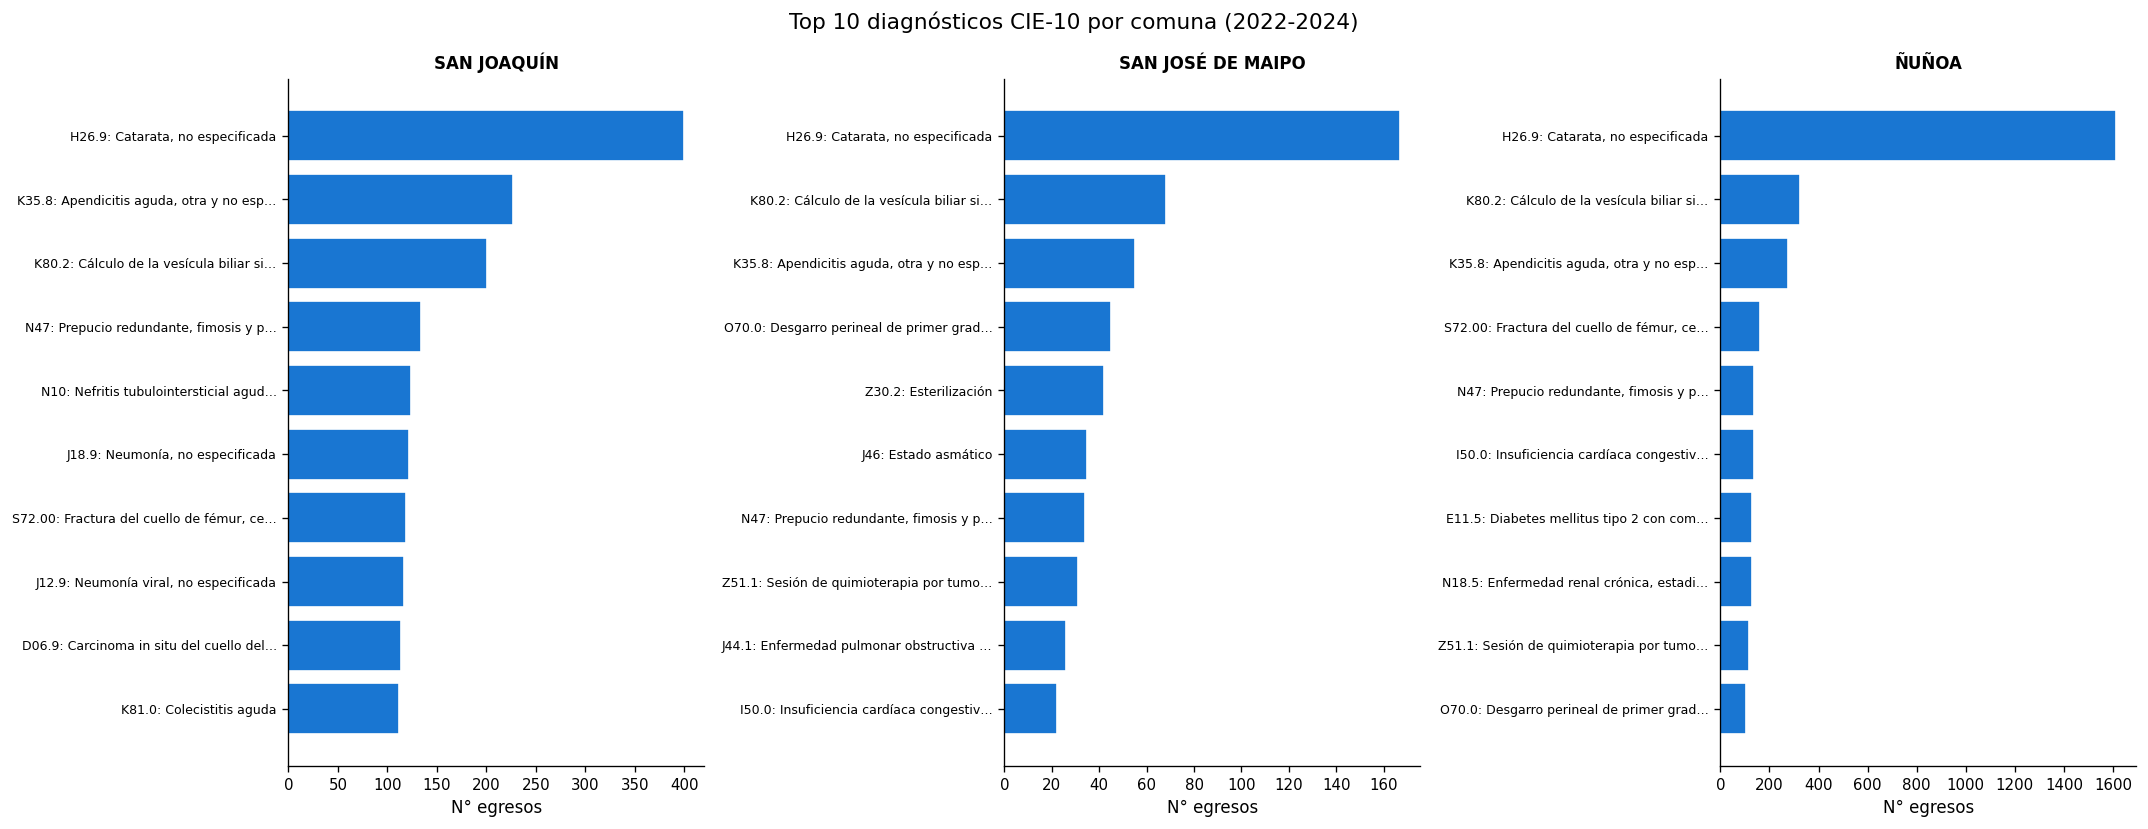

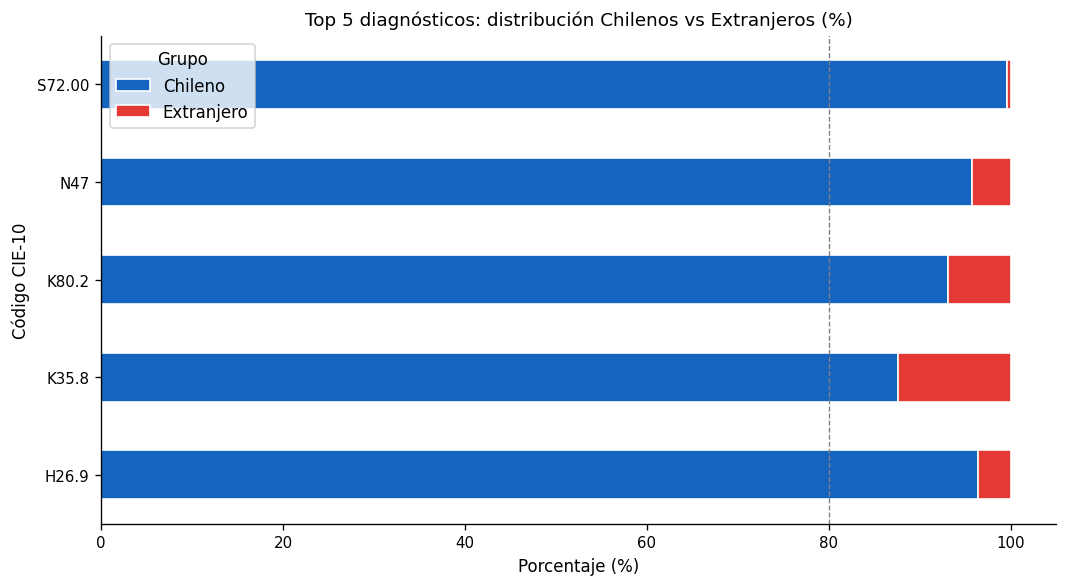

In [ ]:
# Top 10 por comuna
fig, axes = plt.subplots(1, 3, figsize=(18, 7))
fig.suptitle("Top 10 diagnósticos CIE-10 por comuna (2022-2024)", fontsize=13)

for ax, (comuna, grupo) in zip(axes, grd_dx.groupby('COMUNA')):
    top = (
        grupo.groupby(['DX1', 'Descripcion'])
        .size().reset_index(name='N')
        .sort_values('N', ascending=False).head(10)
    )
    top['etiqueta'] = top.apply(
        lambda r: f"{r['DX1']}: {str(r['Descripcion'])[:32]}…"
                  if pd.notna(r['Descripcion']) and len(str(r['Descripcion'])) > 32
                  else (f"{r['DX1']}: {r['Descripcion']}" if pd.notna(r['Descripcion'])
                        else r['DX1']),
        axis=1
    )
    top_s = top.sort_values('N', ascending=True)
    ax.barh(top_s['etiqueta'], top_s['N'], color='#1976D2', edgecolor='white')
    ax.set_title(f"{comuna}", fontsize=10, fontweight='bold')
    ax.set_xlabel("N° egresos")
    ax.tick_params(axis='y', labelsize=7.5)

plt.tight_layout()
plt.savefig('top10_cie10.png', bbox_inches='tight', dpi=150)
plt.show()

# Top 5 diagnósticos: Chilenos vs Extranjeros (global 3 comunas)
top5_dx = (
    grd_dx.groupby('DX1').size()
    .sort_values(ascending=False).head(5).index.tolist()
)

sub_top5 = grd_dx[grd_dx['DX1'].isin(top5_dx)].copy()
cross = (
    sub_top5.groupby(['DX1', 'GRUPO_NAC'])
    .size().reset_index(name='N')
    .pivot(index='DX1', columns='GRUPO_NAC', values='N')
    .fillna(0)
)
cross_pct = cross.div(cross.sum(axis=1), axis=0) * 100

fig2, ax2 = plt.subplots(figsize=(9, 5))
cross_pct.plot(kind='barh', ax=ax2, stacked=True,
               color=['#1565C0', '#E53935'], edgecolor='white')
ax2.set_title("Top 5 diagnósticos: distribución Chilenos vs Extranjeros (%)", fontsize=11)
ax2.set_xlabel("Porcentaje (%)")
ax2.set_ylabel("Código CIE-10")
ax2.legend(title="Grupo")
ax2.axvline(x=80, color='gray', linestyle='--', linewidth=0.8)
plt.tight_layout()
plt.savefig('cie10_nac_stacked.png', bbox_inches='tight', dpi=150)
plt.show()

---
## B.5 Severidad de los egresos

La variable `IR_29301_SEVERIDAD` clasifica la complejidad del egreso según la metodología GRD: **0** = Sin gravedad, **1** = Menor, **2** = Moderada, **3** = Mayor. Se analiza su distribución por comuna y se compara entre grupos de nacionalidad.

Distribución de severidad (%) por comuna:


COMUNA,SAN JOAQUÍN,SAN JOSÉ DE MAIPO,ÑUÑOA
SEV_LABEL,,,
Sin gravedad,17.0,19.5,29.1
Menor,32.8,41.2,25.7
Moderada,27.6,17.7,23.7
Mayor,22.6,21.6,21.5
Sin información,0.0,0.0,0.0


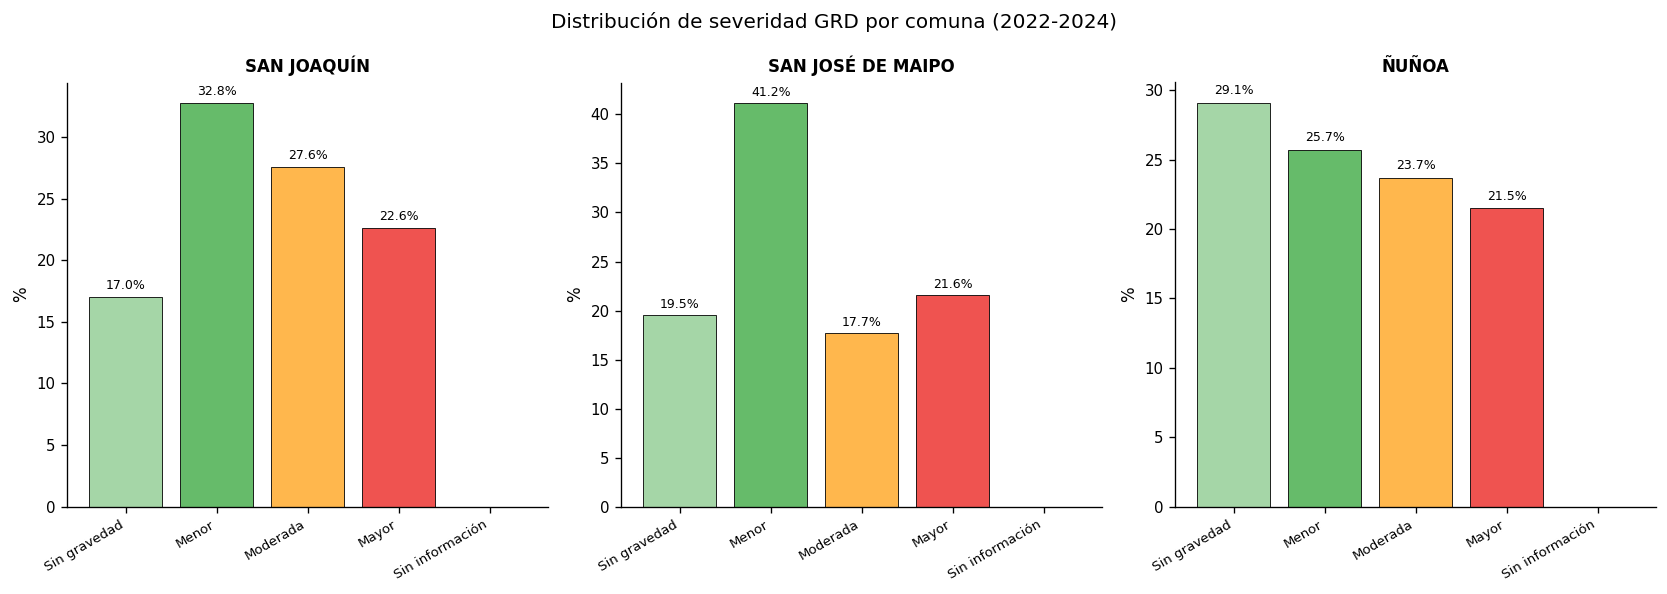


Severidad (%) por grupo de nacionalidad:


GRUPO_NAC,Chileno,Extranjero
SEV_LABEL,,
Sin gravedad,24.5,15.6
Menor,28.4,44.9
Moderada,24.5,25.7
Mayor,22.6,13.9
Sin información,0.0,0.0


In [ ]:
SEV_MAP = {'0': 'Sin gravedad', '1': 'Menor', '2': 'Moderada', '3': 'Mayor'}
SEV_ORDEN = ['Sin gravedad', 'Menor', 'Moderada', 'Mayor', 'Sin información']
SEV_COLORES = {
    'Sin gravedad': '#A5D6A7',
    'Menor':        '#66BB6A',
    'Moderada':     '#FFB74D',
    'Mayor':        '#EF5350',
    'Sin información': '#BDBDBD'
}

grd_com['SEV_LABEL'] = grd_com['IR_29301_SEVERIDAD'].map(SEV_MAP).fillna('Sin información')

# Tabla de distribución porcentual por comuna
sev_pct = (
    grd_com.groupby(['COMUNA', 'SEV_LABEL'])
    .size().reset_index(name='N')
)
sev_pct['PCT'] = (
    sev_pct['N'] / sev_pct.groupby('COMUNA')['N'].transform('sum') * 100
).round(1)
print("Distribución de severidad (%) por comuna:")
display(
    sev_pct.pivot(index='SEV_LABEL', columns='COMUNA', values='PCT')
    .reindex(SEV_ORDEN).fillna(0).round(1)
)

# Gráfico
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
fig.suptitle("Distribución de severidad GRD por comuna (2022-2024)", fontsize=12)

for ax, (comuna, grupo) in zip(axes, grd_com.groupby('COMUNA')):
    counts = grupo['SEV_LABEL'].value_counts().reindex(SEV_ORDEN, fill_value=0)
    pct_vals = (counts / counts.sum() * 100).round(1)
    bars = ax.bar(
        pct_vals.index, pct_vals.values,
        color=[SEV_COLORES.get(l, '#90A4AE') for l in pct_vals.index],
        edgecolor='black', linewidth=0.5
    )
    ax.set_title(f"{comuna}", fontsize=10, fontweight='bold')
    ax.set_ylabel("%")
    ax.set_xticklabels(pct_vals.index, rotation=30, ha='right', fontsize=8)
    for bar, val in zip(bars, pct_vals.values):
        if val > 2:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.4,
                    f'{val:.1f}%', ha='center', va='bottom', fontsize=7.5)

plt.tight_layout()
plt.savefig('severidad_comunas.png', bbox_inches='tight', dpi=150)
plt.show()

# Severidad por grupo de nacionalidad
sev_nac = (
    grd_com.groupby(['GRUPO_NAC', 'SEV_LABEL'])
    .size().reset_index(name='N')
)
sev_nac['PCT'] = (
    sev_nac['N'] / sev_nac.groupby('GRUPO_NAC')['N'].transform('sum') * 100
).round(1)
print("\nSeveridad (%) por grupo de nacionalidad:")
display(
    sev_nac.pivot(index='SEV_LABEL', columns='GRUPO_NAC', values='PCT')
    .reindex(SEV_ORDEN).fillna(0).round(1)
)

---
## B.6 Tipo de Alta

Se analiza la variable `TIPOALTA`, que describe la condición en que el paciente egresó. Se simplifican las categorías más frecuentes para facilitar la visualización. Se revisa si existen diferencias en la proporción de fallecidos o traslados entre comunas.

In [ ]:
print("Valores de TIPOALTA (top 15):")
print(grd_com['TIPOALTA'].value_counts(dropna=False).head(15).to_string())

def simplificar_alta(val):
    if pd.isna(val):
        return 'Sin información'
    v = str(val).upper()
    if 'FALLECIDO' in v or 'FALLECI' in v:
        return 'Fallecido'
    if 'HOSPITALIZACI' in v and 'DOMICILI' in v:
        return 'Hosp. domiciliaria'
    if 'DOMICILIO' in v:
        return 'Domicilio'
    if 'TRASLADO' in v:
        return 'Traslado'
    if 'FUGA' in v or 'RETIRO' in v or 'VOLUNTARI' in v:
        return 'Retiro voluntario'
    if 'LARGA ESTADÍA' in v or 'LARGA ESTADIA' in v:
        return 'Larga estadía'
    return 'Otro'

grd_com['ALTA_SIMPLE'] = grd_com['TIPOALTA'].apply(simplificar_alta)

print("\nCategorías simplificadas:")
print(grd_com['ALTA_SIMPLE'].value_counts().to_string())

# Tabla comparativa
alta_pct = (
    grd_com.groupby(['COMUNA', 'ALTA_SIMPLE'])
    .size().reset_index(name='N')
)
alta_pct['PCT'] = (
    alta_pct['N'] / alta_pct.groupby('COMUNA')['N'].transform('sum') * 100
).round(1)
print("\nTipo de alta (%) por comuna:")
display(
    alta_pct.pivot(index='ALTA_SIMPLE', columns='COMUNA', values='PCT').fillna(0).round(1)
)

Valores de TIPOALTA (top 15):
TIPOALTA
DOMICILIO                                        28798
FALLECIDO                                          949
HOSPITALIZACIÓN DOMICILIARIA                       947
DERIVACIÓN OTRO HOSPITAL DEL SERVICIO              689
ALTA VOLUNTARIA                                    342
DERIVACIÓN A OTROS CENTROS (CÁRCEL, HOGAR DE       267
DERIVACIÓN OTRO HOSPITAL DE LA RED NACIONAL        176
DERIVACIÓN INST. PRIVADA (COMPRA DE SERVICIOS       93
FUGA DEL PACIENTE                                   48
DERIVACIÓN INST. PRIVADA (VOLUNTARIO)               32

Categorías simplificadas:
ALTA_SIMPLE
Domicilio             28798
Otro                   1225
Fallecido               949
Hosp. domiciliaria      947
Retiro voluntario       422

Tipo de alta (%) por comuna:


COMUNA,SAN JOAQUÍN,SAN JOSÉ DE MAIPO,ÑUÑOA
ALTA_SIMPLE,,,
Domicilio,88.8,87.9,89.4
Fallecido,3.3,1.4,3.0
Hosp. domiciliaria,4.1,5.1,1.7
Otro,2.3,4.4,4.8
Retiro voluntario,1.5,1.2,1.2


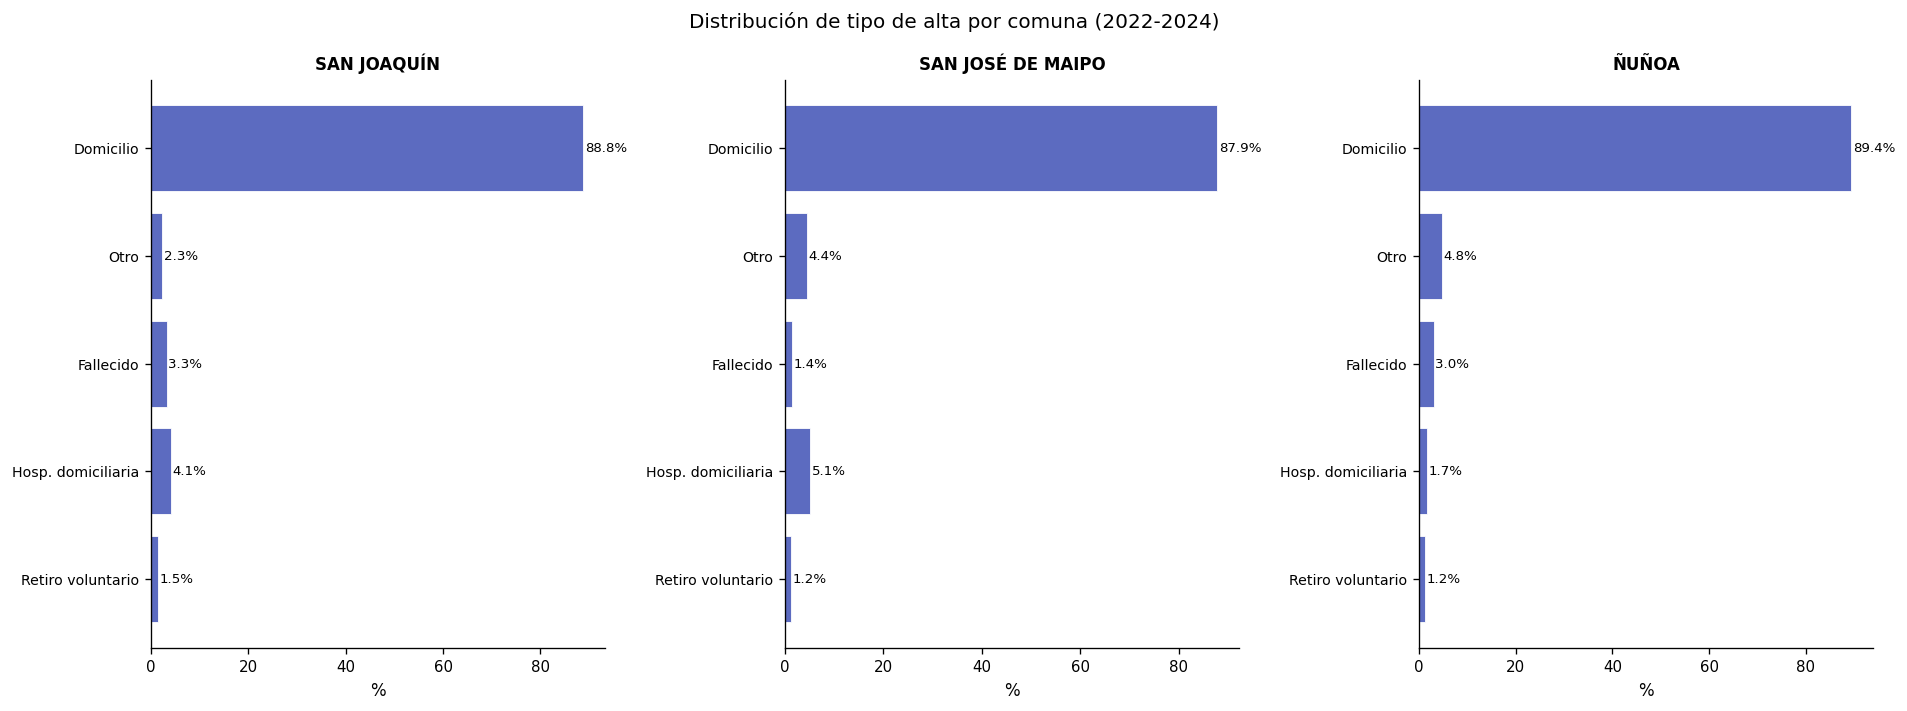

Porcentaje de fallecidos por grupo de nacionalidad:


,GRUPO_NAC,Pct_Fallecido
0,Chileno,3.10
1,Extranjero,1.11


In [ ]:
orden_alta = (
    grd_com['ALTA_SIMPLE'].value_counts().head(7).index.tolist()
)

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle("Distribución de tipo de alta por comuna (2022-2024)", fontsize=12)

for ax, (comuna, grupo) in zip(axes, grd_com.groupby('COMUNA')):
    counts = grupo['ALTA_SIMPLE'].value_counts().reindex(orden_alta, fill_value=0)
    pct_vals = (counts / counts.sum() * 100).round(1)
    bars = ax.barh(
        pct_vals.index[::-1], pct_vals.values[::-1],
        color='#5C6BC0', edgecolor='white', linewidth=0.5
    )
    ax.set_title(f"{comuna}", fontsize=10, fontweight='bold')
    ax.set_xlabel("%")
    ax.tick_params(axis='y', labelsize=8.5)
    for bar, val in zip(bars, pct_vals.values[::-1]):
        ax.text(val + 0.3, bar.get_y() + bar.get_height() / 2,
                f'{val:.1f}%', va='center', fontsize=8)

plt.tight_layout()
plt.savefig('tipo_alta_comunas.png', bbox_inches='tight', dpi=150)
plt.show()

# Fallecidos por grupo de nacionalidad
fall_nac = (
    grd_com.groupby('GRUPO_NAC')
    .apply(lambda x: (x['ALTA_SIMPLE'] == 'Fallecido').mean() * 100)
    .reset_index(name='Pct_Fallecido')
    .round(2)
)
print("Porcentaje de fallecidos por grupo de nacionalidad:")
display(fall_nac)

---
## B.7 Mapa coroplético

Se construye un mapa coroplético con la tasa de egresos hospitalarios por 10.000 habitantes para cada comuna. La población base corresponde a las proyecciones INE 2022. Las geometrías comunales se obtienen de la base GADM (nivel 3). Si la descarga falla (sin internet o el archivo es muy grande), se genera un gráfico de barras equivalente.

Tasa de egresos hospitalarios por 10.000 hab.:


,COMUNA,EGRESOS,POB,TASA_10K
0,SAN JOAQUÍN,12206,95039,1284.3
1,SAN JOSÉ DE MAIPO,2844,17303,1643.6
2,ÑUÑOA,17291,239323,722.5



Descargando geometrías comunales desde GADM…
No se pudo cargar la geometría: HTTP Error 404: Not Found


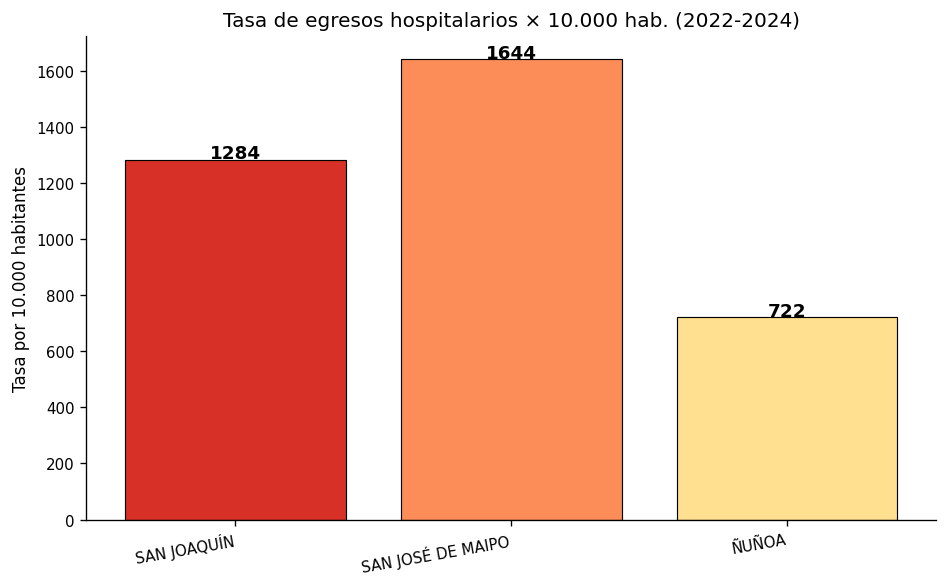


Nota: para el mapa coroplético, descargue el shapefile de comunas desde
https://www.bcn.cl/siit/mapas_vectoriales y cárguelo con gpd.read_file()


In [ ]:
import geopandas as gpd
import unicodedata

# Población comunal (proyección INE 2022)
POB = {
    'ÑUÑOA':             239_323,
    'SAN JOAQUÍN':        95_039,
    'SAN JOSÉ DE MAIPO':  17_303
}

tasa_df = (
    grd_com.groupby('COMUNA')
    .size().reset_index(name='EGRESOS')
)
tasa_df['POB'] = tasa_df['COMUNA'].map(POB)
tasa_df['TASA_10K'] = (tasa_df['EGRESOS'] / tasa_df['POB'] * 10_000).round(1)
print("Tasa de egresos hospitalarios por 10.000 hab.:")
display(tasa_df)

def norm_str(s):
    """Normaliza texto a ASCII mayúscula para comparaciones."""
    return unicodedata.normalize('NFD', str(s).upper()).encode('ascii', 'ignore').decode()

MAP_OK = False
try:
    # Shapefile de comunas de Chile — GADM nivel 3
    # (Descarga ~20 MB; puede tomar 1-2 min según conexión)
    GEO_URL = "https://geodata.ucdavis.edu/gadm/gadm4.1/shp/gadm41_CHL_3.zip"
    print("\nDescargando geometrías comunales desde GADM…")
    comunas_geo = gpd.read_file(GEO_URL)

    name_col = 'NAME_3'
    comunas_geo['_norm'] = comunas_geo[name_col].apply(norm_str)
    mis_norm = {norm_str(c): c for c in MY_COMUNAS}

    geo_sel = comunas_geo[comunas_geo['_norm'].isin(mis_norm.keys())].copy()
    geo_sel['COMUNA'] = geo_sel['_norm'].map(mis_norm)
    geo_sel = geo_sel.merge(tasa_df[['COMUNA', 'TASA_10K', 'EGRESOS']], on='COMUNA', how='left')

    if len(geo_sel) >= 1:
        MAP_OK = True
        fig, ax = plt.subplots(figsize=(8, 7))
        geo_sel.plot(
            column='TASA_10K', ax=ax, cmap='YlOrRd',
            legend=True,
            legend_kwds={'label': 'Tasa egresos × 10.000 hab.', 'shrink': 0.6},
            edgecolor='black', linewidth=0.8, missing_kwds={'color': '#eeeeee'}
        )
        for _, row in geo_sel.iterrows():
            c = row.geometry.centroid
            ax.annotate(
                f"{str(row['COMUNA']).title()}\n{row['TASA_10K']:.0f}/10k",
                xy=(c.x, c.y), ha='center', fontsize=9,
                bbox=dict(boxstyle='round,pad=0.2', facecolor='white', alpha=0.75)
            )
        ax.set_title("Tasa de egresos hospitalarios por 10.000 hab.\n(comunas asignadas, 2022-2024)",
                     fontsize=12)
        ax.axis('off')
        plt.tight_layout()
        plt.savefig('mapa_coropletico.png', bbox_inches='tight', dpi=150)
        plt.show()
    else:
        print("No se encontraron comunas en el archivo geográfico.")
except Exception as e:
    print(f"No se pudo cargar la geometría: {e}")

if not MAP_OK:
    # Alternativa visual si no hay geometría disponible
    fig, ax = plt.subplots(figsize=(8, 5))
    colores_mapa = ['#d73027', '#fc8d59', '#fee090']
    bars = ax.bar(
        tasa_df['COMUNA'], tasa_df['TASA_10K'],
        color=colores_mapa, edgecolor='black', linewidth=0.7
    )
    for bar, val in zip(bars, tasa_df['TASA_10K']):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 5,
                f'{val:.0f}', ha='center', fontsize=11, fontweight='bold')
    ax.set_title("Tasa de egresos hospitalarios × 10.000 hab. (2022-2024)", fontsize=12)
    ax.set_ylabel("Tasa por 10.000 habitantes")
    ax.set_xlabel("")
    ax.set_xticklabels(tasa_df['COMUNA'], rotation=10, ha='right')
    plt.tight_layout()
    plt.savefig('mapa_coropletico_barras.png', bbox_inches='tight', dpi=150)
    plt.show()
    print("\nNota: para el mapa coroplético, descargue el shapefile de comunas desde")
    print("https://www.bcn.cl/siit/mapas_vectoriales y cárguelo con gpd.read_file()")

---
## B.8 Tabla resumen

Se construye una tabla resumen con los indicadores principales por comuna: número de egresos, días de hospitalización promedio, porcentaje de extranjeros, porcentaje de fallecidos, distribución de severidad, tasa de egresos y diagnóstico más frecuente. La tabla se exporta en formato CSV con codificación UTF-8 BOM para compatibilidad con Excel.

In [ ]:
resumen = (
    grd_com.groupby('COMUNA')
    .agg(
        N_egresos             = ('DIAS_HOSP', 'count'),
        Media_dias_hosp       = ('DIAS_HOSP', 'mean'),
        Mediana_dias_hosp     = ('DIAS_HOSP', 'median'),
        Pct_extranjero        = ('GRUPO_NAC',   lambda x: (x == 'Extranjero').mean() * 100),
        Pct_fallecido         = ('ALTA_SIMPLE', lambda x: (x == 'Fallecido').mean() * 100),
        Pct_sev_mayor         = ('SEV_LABEL',   lambda x: (x == 'Mayor').mean() * 100),
        Pct_sev_moderada      = ('SEV_LABEL',   lambda x: (x == 'Moderada').mean() * 100),
        Top_DX1               = ('DX1',         lambda x: x.value_counts().idxmax() if len(x) else None),
    )
    .round(2)
    .reset_index()
)

resumen['Poblacion_INE_2022'] = resumen['COMUNA'].map(POB)
resumen['Tasa_egresos_x10k'] = (
    resumen['N_egresos'] / resumen['Poblacion_INE_2022'] * 10_000
).round(1)

# cie10_ref tiene columna 'Codigo' (no 'DX1', que solo existe en el merge temporal de B.4)
resumen = resumen.merge(
    cie10_ref[['Codigo', 'Descripcion']].rename(columns={'Codigo': 'Codigo_cie10'})
        .drop_duplicates('Codigo_cie10'),
    left_on='Top_DX1', right_on='Codigo_cie10', how='left'
)
resumen.rename(columns={'Descripcion': 'Desc_top_DX1'}, inplace=True)
resumen.drop(columns=['Codigo_cie10'], inplace=True)

print("Tabla resumen final:")
display(resumen)

# Exportar
csv_path = 'resumen_GRD_comunas.csv'
resumen.to_csv(csv_path, index=False, encoding='utf-8-sig')
print(f"\n✓ Tabla guardada en: {csv_path}")

Tabla resumen final:


,COMUNA,N_egresos,Media_dias_hosp,Mediana_dias_hosp,Pct_extranjero,Pct_fallecido,Pct_sev_mayor,Pct_sev_moderada,Top_DX1,Poblacion_INE_2022,Tasa_egresos_x10k,Desc_top_DX1
0,SAN JOAQUÍN,12206,23.59,3.0,9.08,3.25,22.57,27.58,H26.9,95039,1284.3,"Catarata, no especificada"
1,SAN JOSÉ DE MAIPO,2844,18.85,2.0,2.22,1.41,21.59,17.69,H26.9,17303,1643.6,"Catarata, no especificada"
2,ÑUÑOA,17291,20.97,2.0,8.80,2.96,21.51,23.69,H26.9,239323,722.5,"Catarata, no especificada"



✓ Tabla guardada en: resumen_GRD_comunas.csv


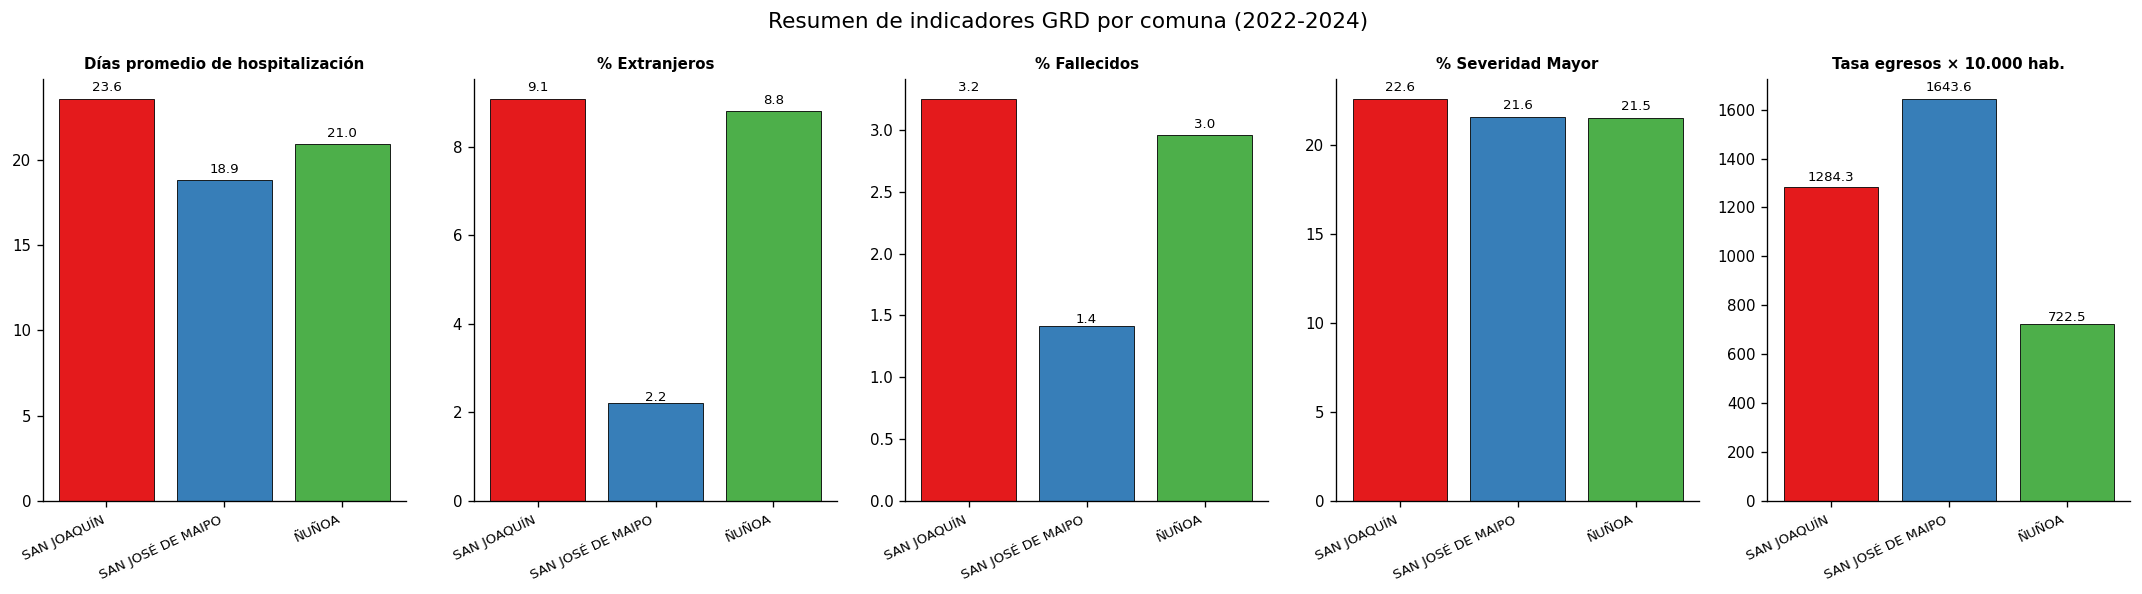


=== Archivos generados ===
  ✓  resumen_GRD_comunas.csv
  ✓  boxplot_dias_hosp.png
  ✓  boxplot_nac.png
  ✓  barras_media_nac.png
  ✓  pct_extranjeros_año.png
  ✓  top10_cie10.png
  ✓  cie10_nac_stacked.png
  ✓  severidad_comunas.png
  ✓  tipo_alta_comunas.png
  ✓  resumen_indicadores.png


In [ ]:
# Visualización comparativa de indicadores clave
indicadores = [
    ('Media_dias_hosp',   'Días promedio de hospitalización'),
    ('Pct_extranjero',    '% Extranjeros'),
    ('Pct_fallecido',     '% Fallecidos'),
    ('Pct_sev_mayor',     '% Severidad Mayor'),
    ('Tasa_egresos_x10k', 'Tasa egresos × 10.000 hab.')
]

fig, axes = plt.subplots(1, len(indicadores), figsize=(18, 5))
fig.suptitle("Resumen de indicadores GRD por comuna (2022-2024)", fontsize=13)
colores_res = ['#e41a1c', '#377eb8', '#4daf4a']

for ax, (col, titulo) in zip(axes, indicadores):
    bars = ax.bar(resumen['COMUNA'], resumen[col],
                  color=colores_res, edgecolor='black', linewidth=0.5)
    ax.set_title(titulo, fontsize=9, fontweight='bold')
    ax.set_xticklabels(resumen['COMUNA'], rotation=25, ha='right', fontsize=8)
    for bar, val in zip(bars, resumen[col]):
        ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() * 1.02,
                f'{val:.1f}', ha='center', fontsize=8)

plt.tight_layout()
plt.savefig('resumen_indicadores.png', bbox_inches='tight', dpi=150)
plt.show()

print("\n=== Archivos generados ===")
import os
archivos = [
    'resumen_GRD_comunas.csv',
    'boxplot_dias_hosp.png',
    'boxplot_nac.png',
    'barras_media_nac.png',
    'pct_extranjeros_año.png',
    'top10_cie10.png',
    'cie10_nac_stacked.png',
    'severidad_comunas.png',
    'tipo_alta_comunas.png',
    'resumen_indicadores.png',
]
for f in archivos:
    existe = '✓' if os.path.exists(f) else '✗ (aún no generado)'
    print(f"  {existe}  {f}")